# ERP analysis using MNE


**Important note**

This notebook contains **only** the code for the experiments of `A7_experiment_log.md`. Note that the preprocessing settings have changed over the course of the experiment log (these changes are reffered to as "Mod_x"). These changes are not implemented in this notebook. Therefore, the code snippets here are not suitable for running and returning the same results as in the real code and experiment log.

The preprocessing here is there untouched. Changes such as turning off baseline correction, have not been implemented here. See `A7_experiment_log.md` for all changes made.


## Top-down view onto this notebook

##### Dynamic stopping (programming)
1. You will answer a few theoretical questions
1. You will look at ERP data collected from an experiment that looks a lot like the AMUSE paradigm ([video showing the AMUSE paradigm
](https://youtu.be/l2V5pMdYYfA?t=123)). But, instead of tones we present 6 monosyllabic words played on the 6 speakers surrounding the subject.
1. You will implement a dynamic stopping procedure in a simulated online experiment.
    
##### Ethics (presentation/discussion)
1. You will dive into the ethics of an aspect of BCI you're interested in (we'll give you a few starting points) 
1. You will introduce your peers to your chosen topic by creating and posting *one* of the following:
    * an informational video 
    * a **short** report/summary document
    * a video/written summary of a discussion that you had amongst your teammates
    * any other medium you want to use! 🥳

# Dynamic Stopping

## Exercise 2: Import, preprocess and inspect the data

#### Experimental setup:
In every trial the patient/user (from now on 'participant') has to focus on a single word from the set of 6 words. Each word/stimulus is played once per iteration. This means that an iteration consists of 6 words/stimuli, of which one is the target word. A sequence of 15 iterations, adding up to 90 stimuli, form one complete trial. The goal of a single trial is to determine what the target word is. This means that each iteration in a single trial shares the same target word. However, the order in which words are presented between iterations in a single trial may differ. To summarise, each trial has a single target word. Each trial consists of 15 iterations in which all 6 words are played once.

#### General EEG data information:
The data provided contains three file types: `.vhdr`, `.vmrk`, `.eeg`.  In the each `.vhdr` file you will find information about all recorded channels. Five of the channels listed are non-EEG channels:
* The EMG channel records an electromyogram. This is muscle activity.
* The GSR channel records the galvanic skin response. This is sweat gland activity which is indicative of stress levels and excitation.
* The Respi channel records respiration activity.
* The Pulse channel records the heart pulses by shining a red light on the finger and recording how much of it is reflected back.
* The Optic channel is an optical sensor focused on a portion of the screen that flashes every time an event happens in order to detect potential interference/delay between the time point the computer issues a stimulus and the time the stimulus is actually presented on the screen to the user.

Some of these channels can be used to remove artefacts from the EEG signal and better phase-locking the signals. For our experiment though they aren't relevant.

In the `.vhdr` files you will also find the resolution ( $\mu V$ steps) of each channel and the impedance (kOhm) of all channels, a higher impedance results in a higher noise level.

In each `.vmrk` you will find the event marker information. Each stimulus/event has an `event_id`. In our case, non-target words have event_ids $[101, 102, ..., 106]$. We have 6 different words. In every trial exactly 1 of them is in the target role. The target words are indicated by $[111,112, ..., 116]$. So, the last digit indicates the word id, the second digit indicates whether a stimulus is a target $(1)$ or non-target $(0)$.

Lastly, each `.eeg` file contains the recorded signals encoded in binary values and stored as integers. Increasing the value by 1 corresponds to a step value of 0.1 $\mu V$, which is the resolution denoted in the header (`.vhdr`) file.

Your task now is to:

1. Get the ERP data from Brightspace.
1. (Optional) Inspect a single `.vhdr` and `.vmrk` file. You can open them with a text editor such as Notepad (or even VS code). Check where in the file the sampling resolution of the EEG channels is given. Has the frequency range been limited? If so, to what band? What is the sampling rate? Can you guess what was the intended temporal difference between 2 successive stimulus onsets? What could be the reason for this difference not being constant?
1. (Optional) Inspect the preprocessing functions we've provided and write down a short description of what each function does at every step. If you're unsure about some functions, look up the documentation of the relevant library.
    * In the creation of epochs, we decimate the sampling rate. Would this cause an aliasing problem? Why or why not?
1. Plot the average ERP response of a word of your choice for when it is the target condition vs. the non-target condition. Can you spot the difference in average response when a target vs. non-target stimulus is presented? Describe this in terms of amplitudes, inter-channel variance and delay of EEG components. See: [MNE Epoch documentation](https://mne.tools/stable/generated/mne.Epochs.html) and [MNE Evoked documentation](https://mne.tools/stable/generated/mne.Evoked.html).

In [2]:
import mne
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split, cross_val_score # added cross_val_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
import sklearn.metrics as metrics
import scipy as sp
import scipy.stats as stats
import warnings

warnings.simplefilter(action='ignore', category=RuntimeWarning)
mne.set_log_level('WARNING')

np.random.seed(42)

In [3]:
# Preparations

def load_and_preprocess_raw(header_file, filter_band=(0.5, 16)):
    non_eeg_channels = ["EOGvu", "x_EMGl", "x_GSR", "x_Respi", "x_Pulse", "x_Optic"]
    raw = mne.io.read_raw_brainvision(header_file, misc=non_eeg_channels, preload=True)
    raw.set_montage("standard_1020")
    raw.filter(*filter_band, method="iir")
    raw.pick_types(eeg=True)
    return raw

def epoch_raw(raw, decimate=10):
    target_ids = list(range(111, 117))     # [111, 112, 113, 114, 115, 116]
    non_target_ids = list(range(101, 107)) # [101, 102, 103, 104, 105, 106]

    event_id = {f"Word_{i-110}/Target": i for i in target_ids}
    # {'Word_1/Target': 111, 'Word_2/Target': 112, 'Word_3/Target': 113, 'Word_4/Target': 114, 'Word_5/Target': 115, 'Word_6/Target': 116}
    
    event_id.update({f"Word_{i-100}/NonTarget": i for i in non_target_ids})
    # Same idea for non targets
    
    evs = mne.events_from_annotations(raw)[0]

    # print(evs.shape) # (548,3)
    # print(evs)
    # [[     0      0  99999]
    #  [  7538      0    201]
    #  [ 12077      0    101]
    #  ...
    #  [216368      0    101]
    #  [216621      0    103]
    #  [219940      0    255]]
    
    epoch = mne.Epochs(raw, events=evs, event_id=event_id, decim=decimate,
                      proj=False, tmax=1)

    # Added by me
    #epoch = mne.Epochs(raw, events=evs, event_id=event_id, decim=decimate,
    #                   proj=False, tmax=1, baseline=None)
    return epoch

# Get the data path
data_dir = Path.cwd() / "data_a7" 
header_files = data_dir.glob("auditoryAphasia*.vhdr")

# Load the data, preprocess and slice it into epochs
epochs = list()
for f in header_files:
    raw_data = load_and_preprocess_raw(f)
    epochs.append(epoch_raw(raw_data))

# Overwrite epochs list to save memory
epochs = mne.concatenate_epochs(epochs) # len(epochs) = 3240

# Combine 6 epochs into a single iteration (6 stimuli together form a single iteration)
iterations = [epochs[i:i+6] for i in np.arange(0, epochs.events.shape[0],6)] # for loop goes from 0 to 3234 in steps of 6

# Assert that each iteration contains exactly 1 Target
assert all([len(iteration["Target"]) == 1 for iteration in iterations]), "Number of targets in single iterations is unequal to 1."

# 15 iterations form a single trial
trials = [iterations[i:i+15] for i in np.arange(0,len(iterations),15)]

In [4]:
# Printing the objects for visualisation
print("raw_data = ",raw_data)
print("\nepochs = \n",epochs)
print("\nlen(epochs) = ", len(epochs))

#print("\n iterations[0] = \n",iterations[0])
print("len(iterations) = ", len(iterations), " (each consists of 6 epochs)")
print("len(trials) = ", len(trials), " (each consists of 15 iterations)")

print("\nWe have 36 trials, each consists of 15 iterations (making 36 * 15 = 540 iterations in total)")
print("Each iteration consists of 6 events/words (making 540 * 6 = 3240 stimuli in total)")
print("This is in line with the total amount of epochs: 3240")

raw_data =  <RawBrainVision | auditoryAphasia_6D_Block1_Run7.eeg, 63 x 220240 (220.2 s), ~105.9 MiB, data loaded>

epochs = 
 <EpochsArray | 3240 events (all good), -0.2 – 1 s (baseline -0.2 – 0 s), ~188.5 MiB, data loaded,
 'Word_1/Target': 90
 'Word_2/Target': 90
 'Word_3/Target': 90
 'Word_4/Target': 90
 'Word_5/Target': 90
 'Word_6/Target': 90
 'Word_1/NonTarget': 450
 'Word_2/NonTarget': 450
 'Word_3/NonTarget': 450
 'Word_4/NonTarget': 450
 and 2 more events ...>

len(epochs) =  3240
len(iterations) =  540  (each consists of 6 epochs)
len(trials) =  36  (each consists of 15 iterations)

We have 36 trials, each consists of 15 iterations (making 36 * 15 = 540 iterations in total)
Each iteration consists of 6 events/words (making 540 * 6 = 3240 stimuli in total)
This is in line with the total amount of epochs: 3240


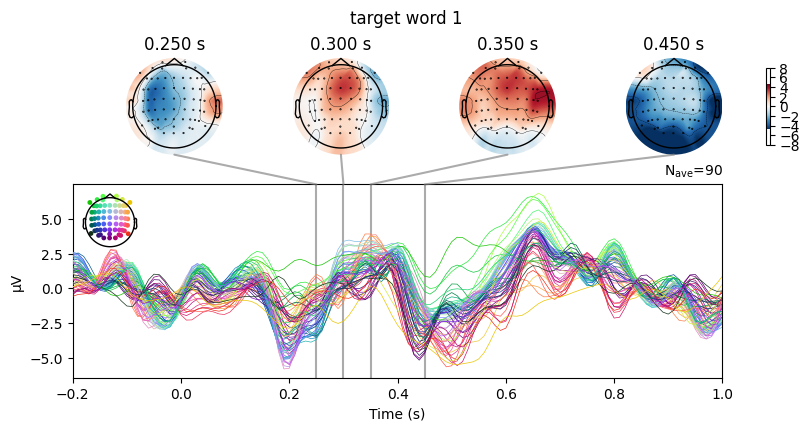

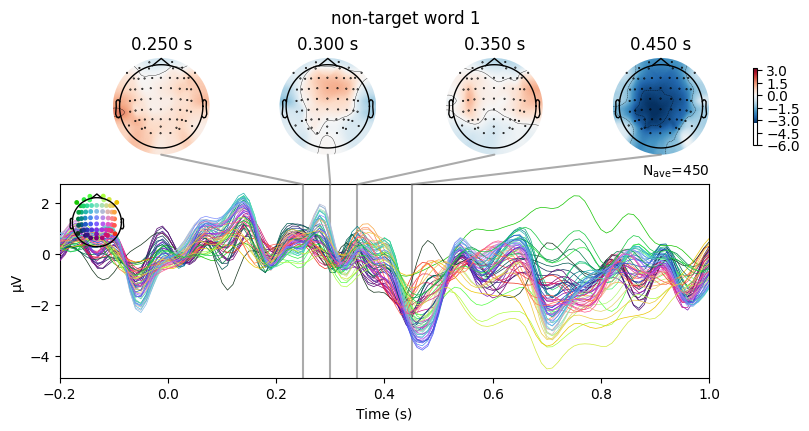

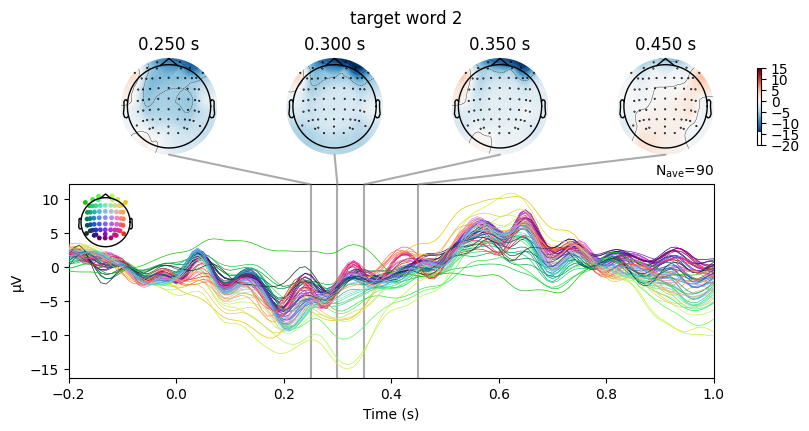

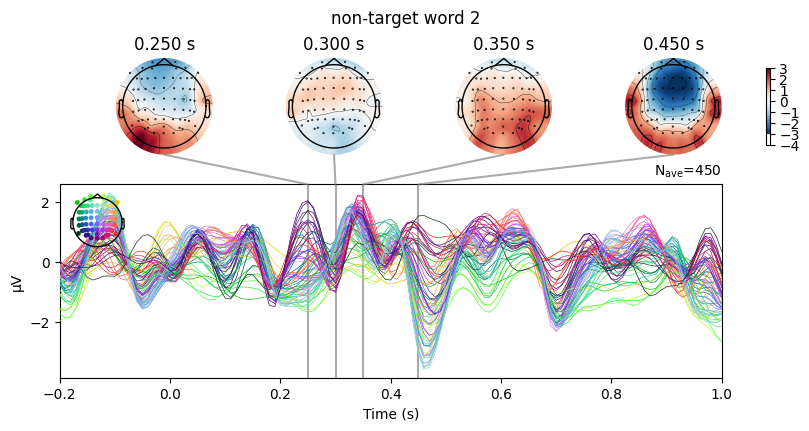

In [5]:
# Solution

# 2:
# Frequency range has been limited to [0,250]Hz. 
# Sampling rate is 1000 Hz.
# The intended temporal difference between 2 stimulus onsets is 250 ms. 
# This means that epochs will overlap a bit. This is not constant up to the ms because of delays in hardware and software, 
# drivers, audio cards, speakers, windows, etc.

# 3:
# -load_and_preprocess_raw() takes the header file and the desired frequency filter range. It separates the EEG from the non-EEG
#   channels, defines the channel layout (montage), applies the band-pass filter and returns the filtered EEG channels.
# -epoch_raw() takes the filtered EEG channels from load_and_preprocess_raw() and slices them up into epochs. The event IDs of 
#   these epochs will be replaced by their conditions: 'Word_i/Target' or 'Word_i/NonTarget' where i ∈ [1,6]. 
# -Event dictionaries like `event_id` are used when extracting epochs from continuous data. The `/` character in the dictionary 
#   keys allows pooling across conditions by requesting partial condition descriptors (i.e., requesting `Word_i` will select all 
#   epochs with that stimulus; requesting `Target` will select all epochs with targets.

# -Decimation of the sampling rate: we have a sampling rate of 1000Hz, as can be seen from the info of our epochs. This is a 
#   lot of data for our purposes.
# -We decimate with a factor 10, meaning every 10 samples, we only actually save 1 in our data. Thus our recorded sampling rate
#   of 1000 Hz becomes a realised sampling rate of 100Hz. Since we filter between 0.5 and 16Hz this is not an issue because 16Hz
#   is still below the Nyquist frequency

# 4:
scalp_times = (0.25, 0.30, 0.35, 0.45)
for i in np.arange(1,6):
    if i < 3:     # to not have a massive notebook
        epochs[f'Word_{i}']["Target"].average().plot_joint(title=f'target word {i}', times=scalp_times)
        epochs[f'Word_{i}']["NonTarget"].average().plot_joint(title=f'non-target word {i}', times=scalp_times)
plt.show()

# It becomes evident that target words have a larger negative response around 200ms, specifically around the sides and 
# the back of the head. 
# Also, the spread of the channels increases at 250ms for the target words. 

## Exercise 3: Calibration
We were able to train a decent LDA classifier on calibration data consisting of only 12 trials. The classifier is trained on individual stimuli and classifies non-targets vs targets. Remember from the previous (last week's) *assignment*: neighbouring time samples probably contain very similar information. We want to save some computing time and thus, we use a common feature preprocessing step for ERP: we average each signal in certain time intervals, which are defined by `clf_ival_boundaries`. We can average, e.g., the time samples of channel Cz between 0.1 and 0.2 seconds post stimulus presentation and this will yield 1 feature dimension to the final feature space. In the example below we use 4 time intervals per channel resulting in a feature dimensionality of $63_{\text{channels}} \cdot 4_{\text{averaged time intervals}} = 252$ features.

1. Inspect the shapes of `calibration_trials` and `calibration_stimuli`, what does every dimension mean? Why do we reshape the data?

1. Inspect how the classifier is trained and validated. Would it be a good idea to shuffle the data prior to making this training/validation split to get an even better performance?

1. Can you find certain time intervals for `clf_ival_boundaries` that lead to better classification performance? Hint: look at the plots from the previous *exercise*.

In [6]:
# ignore
print(len(trials)) # 36 trials, a single one contains 15 iterations of 6 words/events/epochs per iteration. level 1: 36 trials
print(len(np.concatenate(trials).tolist())) # flatten the list, level 2: 36 x 15 = 540 iterations in total
print(len(np.concatenate(np.concatenate(trials).tolist()))) # flatten the list, level 3: 540 x 6 = 3240 words
# levels: 36 -> 36 x 15 -> 36 x 15 x 6 

36
540
3240


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


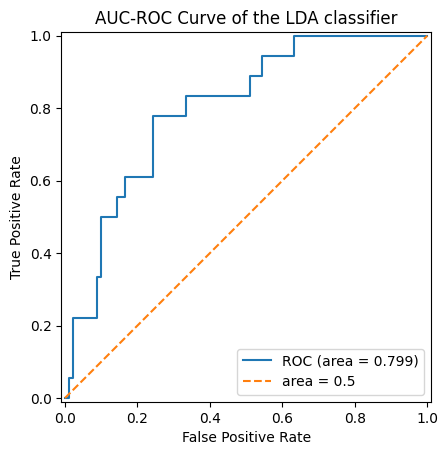

In [7]:
# See cell block below for comments on this funcion
def get_jumping_means(epo, boundaries):

    shape_orig = epo.get_data().shape
    X = np.zeros((shape_orig[0], shape_orig[1], len(boundaries)-1))

    for i in range(len(boundaries)-1):
        idx = epo.time_as_index((boundaries[i], boundaries[i+1]))
        idx_range = list(range(idx[0], idx[1]))
        X[:,:,i] = epo.get_data()[:,:,idx_range].mean(axis=2)
    return X

# Split trials into calibration set and online set
raw_calibration_trials = trials[0:12] # data used to simulate the calibration part of the experiment.
online_trials = trials[12:] # data used to simulate the online experiment.

# Specify the intervals over which to average the timepoints
clf_ival_boundaries = np.array([0.1, 0.2, 0.3, 0.4, 0.5])

# Extract relevant features
# added note: convert (within each trial) all iterations of shape (6, 63, 121) to shape (6, 63, 4)
calibration_trials = np.array([[get_jumping_means(iteration, clf_ival_boundaries) for iteration in trial] for trial in raw_calibration_trials])

# calibration_trials is of shape (12, 15, 6, 63, 4)
# np.prod(calibration_trials.shape[0:3]) = 12 x 15 x 6 = 1080 epochs in total (np.prod multiplies the first 3 dims)

# Reshape our data appropriately for feeding it into LDA
calibration_stimuli = np.reshape(calibration_trials, (np.prod(calibration_trials.shape[0:3]),-1)) # new shape: (1080, 252)
calibration_labels = np.array([[[[1 if event > 107 else 0] for event in iteration.events[:,2]] for iteration in trial] for trial in raw_calibration_trials]).flatten() # shape (1080,), contains only 0's and 1's

### LDA

# Train a classifier on the calibration data and verify that it can classify targets using a subset of the calibration data.
X_train, X_test, y_train, y_test = train_test_split(calibration_stimuli, calibration_labels, test_size=0.1, shuffle=False)
clf = LDA().fit(X_train, y_train)

fpr, tpr, thresholds = metrics.roc_curve(y_test,clf.decision_function(X_test)) # Compute signed distance of stimulus to decision boundary
auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
auc_fig.plot()
plt.plot([0, 1],[0,1], '--')
plt.legend(['ROC (area = %0.3f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
plt.title("AUC-ROC Curve of the LDA classifier")
plt.show()

In [8]:
# ignore (for my own understanding)
print(X_test.shape) # (108, 252)
print(y_test.shape) # (108,)

print("clf.decision_function first 10: \n",clf.decision_function(X_test[:10]))
print("clf.decision_function min: ", min(clf.decision_function(X_test)))
print("clf.decision_function max: ", max(clf.decision_function(X_test)))

# clf.decision_function(X_test) returns non-thresholded measure of decisions (distance to hyperplane)
print("\ny_test first 10: \n",y_test[:10])

# fpr and tpr: np ndarray of shape (30,)
# thresholds: np array of shape (30,)
print("thresholds:\n",thresholds)

print("tpr:\n",tpr)

print("fpr:\n",fpr)

(108, 252)
(108,)
clf.decision_function first 10: 
 [ -1.43300597  -5.87660271  -2.3622788   -5.09106199 -10.92568439
  -4.60532789   0.73113049  -2.58658008  -5.70789874  -6.42659962]
clf.decision_function min:  -14.680607339537737
clf.decision_function max:  9.263359743489996

y_test first 10: 
 [0 0 1 0 0 0 1 0 0 0]
thresholds:
 [         inf   9.26335974   6.23876529   5.94160964   4.53112721
   1.68243545   0.73113049   0.60464001  -0.5518876   -0.92252265
  -1.15716074  -1.43805664  -1.4735866   -2.07418751  -2.3622788
  -3.34821572  -3.40836878  -5.3457048   -5.38738609  -5.80571849
  -5.82080649  -6.42659962  -6.49404172 -14.68060734]
tpr:
 [0.         0.         0.05555556 0.05555556 0.22222222 0.22222222
 0.33333333 0.33333333 0.5        0.5        0.55555556 0.55555556
 0.61111111 0.61111111 0.77777778 0.77777778 0.83333333 0.83333333
 0.88888889 0.88888889 0.94444444 0.94444444 1.         1.        ]
fpr:
 [0.         0.01111111 0.01111111 0.02222222 0.02222222 0.08888889
 

### 14/04/2025 Exp 2: TimeSeriesSplit

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Fold 0...
  Train: #indices=540


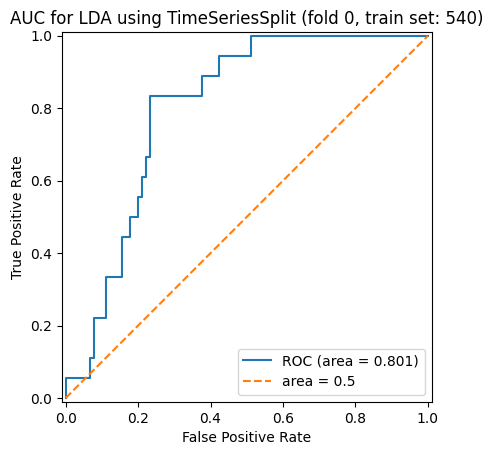

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Fold 1...
  Train: #indices=648


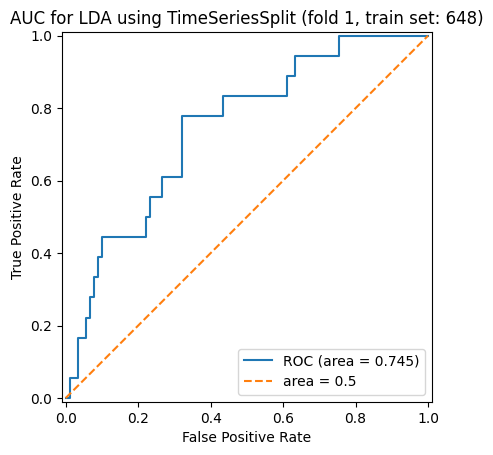

Fold 2...
  Train: #indices=756


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


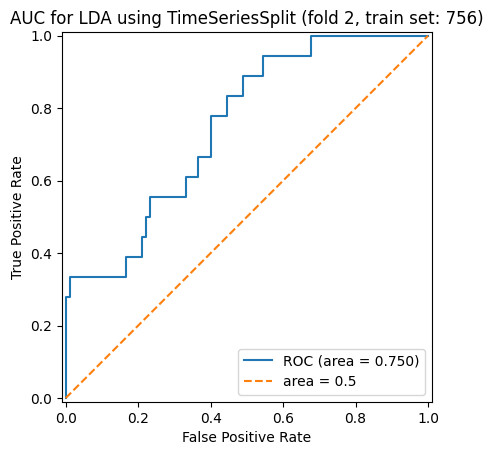

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Fold 3...
  Train: #indices=864


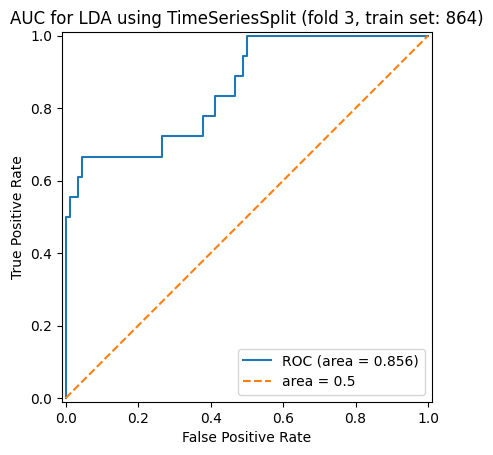

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Fold 4...
  Train: #indices=972


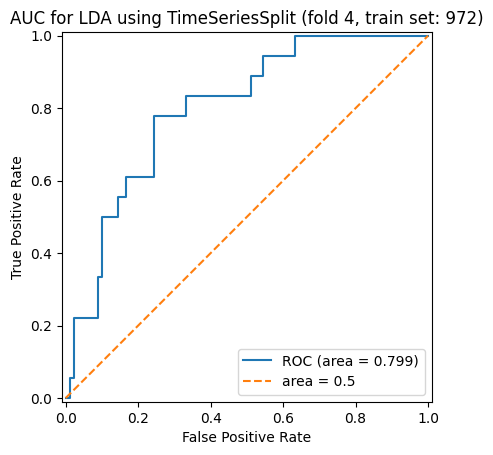

In [ ]:
# 14/04/2025: Exp 2
# Fitting LDA in a different way: with TimeSeriesSplit now
from sklearn.model_selection import TimeSeriesSplit

# Obtain X_train, X_test, y_train, y_test
X = calibration_stimuli
y = calibration_labels
test_size = int(0.1 * len(X)) # 108 (because X is 1080 x 252)

timeseriescv = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=test_size)
tscv_generator = timeseriescv.split(X)

for i, (train_index, test_index) in enumerate(tscv_generator):
    print(f"Fold {i}...")
    print(f"  Train: #indices={len(train_index)}")
    #print(f"  Test:  index={test_index}")
    
    # How to obtain a real X_train and X_test set
    #print("X_train: \n", X[train_index]) #added 
    #print("X_test: \n", X[test_index]) #added

    X_train = X[train_index]
    X_test = X[test_index]
    y_train = y[train_index]
    y_test = y[test_index]

    # Here below comes the same procedure as after the train_test_split function call

    clf = LDA().fit(X_train, y_train)
    fpr, tpr, thresholds = metrics.roc_curve(y_test,clf.decision_function(X_test)) # Compute signed distance of stimulus to decision boundary
    auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
    auc_fig.plot()
    plt.plot([0, 1],[0,1], '--')
    plt.legend(['ROC (area = %0.3f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
    plt.title("AUC for LDA using TimeSeriesSplit (fold {}, train set: {})".format(i,len(X_train)))
    plt.show()


#### Ignore the three code blocks below (they are there for my own understanding)

In [10]:
# Ignore
X = np.array([[1,2],
     [3,4],
     [5,6],
     [7,8],
     [9,10]])
y = np.array([10, 11, 12, 13, 14])
x_tr,x_ts,y_tr,y_ts = train_test_split(X,y,shuffle=False)

print("\ntrain_test_split \n---")
print("train set X:\n",x_tr)
print("train set y:\n",y_tr)

print("test set x:\n",x_ts)
print("test set y:\n",y_ts)


print("\nTimeSeriesSplit \n---")
# Copy pasted from skicit
from sklearn.model_selection import TimeSeriesSplit

#X = np.array([[1, 2], [3, 4], [1, 2], [3, 4], [1, 2], [3, 4]])
#y = np.array([1, 2, 3, 4, 5, 6])
tscv = TimeSeriesSplit(n_splits=3)
print(tscv)
TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None)
for train, test in tscv.split(X):
    print("%s %s" % (train, test))



train_test_split 
---
train set X:
 [[1 2]
 [3 4]
 [5 6]]
train set y:
 [10 11 12]
test set x:
 [[ 7  8]
 [ 9 10]]
test set y:
 [13 14]

TimeSeriesSplit 
---
TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None)
[0 1] [2]
[0 1 2] [3]
[0 1 2 3] [4]


In [11]:
# ignore
# Another example from sklearn

# Default: TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)

import numpy as np
from sklearn.model_selection import TimeSeriesSplit
X = np.array([[1, 2], [3, 4], [1, 2], [3, 4], [1, 2], [3, 4]])
y = np.array([1, 2, 3, 4, 5, 6])
tscv = TimeSeriesSplit()
print(tscv)

for i, (train_index, test_index) in enumerate(tscv.split(X)):
    print(f"Fold {i}:")
    print(f"  Train: index={train_index}")
    print(f"  Test:  index={test_index}")
    
    # How to obtain a real X_train and X_test set
    #print("X_train: \n", X[train_index]) #added 
    #print("X_test: \n", X[test_index]) #added

TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)
Fold 0:
  Train: index=[0]
  Test:  index=[1]
Fold 1:
  Train: index=[0 1]
  Test:  index=[2]
Fold 2:
  Train: index=[0 1 2]
  Test:  index=[3]
Fold 3:
  Train: index=[0 1 2 3]
  Test:  index=[4]
Fold 4:
  Train: index=[0 1 2 3 4]
  Test:  index=[5]


In [12]:
# ignore

# tscv.split(X) returns an (iterable) genenator object
# you can access its values with list(), next(), or a for-loop

# Using list()
#
# The list contains k tuples (k = #splits or #folds)
# Each fold's tuple is of the following shape: (train_idx, test_idx)
# Both train_idx and test_idx are an np array, containing the corresponding indices of that fold

mylist1 = list(tscv.split(X))
print("\nList:\n",mylist1)

# Note that next() is actually exactly the same as:
for i in mylist1:
    print(i)

# Using next
# Be careful, because next(tsvc_generator) removes the current element from the generator, changing the tsvc_generator
print("\n next() method:")
tscv_generator = tscv.split(X)
print(next(tscv_generator))    
print(next(tscv_generator))    
print(next(tscv_generator))    
print(next(tscv_generator))    
print(next(tscv_generator))      

# Using a for-loop
print("\nFor-loop:")
for (train_idx, test_idx) in tscv.split(X):
    print(train_idx, " - ", test_idx)




List:
 [(array([0]), array([1])), (array([0, 1]), array([2])), (array([0, 1, 2]), array([3])), (array([0, 1, 2, 3]), array([4])), (array([0, 1, 2, 3, 4]), array([5]))]
(array([0]), array([1]))
(array([0, 1]), array([2]))
(array([0, 1, 2]), array([3]))
(array([0, 1, 2, 3]), array([4]))
(array([0, 1, 2, 3, 4]), array([5]))

 next() method:
(array([0]), array([1]))
(array([0, 1]), array([2]))
(array([0, 1, 2]), array([3]))
(array([0, 1, 2, 3]), array([4]))
(array([0, 1, 2, 3, 4]), array([5]))

For-loop:
[0]  -  [1]
[0 1]  -  [2]
[0 1 2]  -  [3]
[0 1 2 3]  -  [4]
[0 1 2 3 4]  -  [5]


### 19/04/2025 Exp 3: Compare LDA - sLDA - BT-LDA

In [ ]:
# comparing LDA - BT-LDA - sLDA
# 19/04/2025_Exp_3a

# data is in channel prime order
# evaulation method added from Jan's example_toeplitz_lda_simple.py

from sklearn.pipeline import make_pipeline
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from toeplitzlda.classification import ToeplitzLDA

# See cell block in dump file for documentation on how this function works
def get_jumping_means(epo, boundaries):
    shape_orig = epo.get_data().shape
    X = np.zeros((shape_orig[0], shape_orig[1], len(boundaries)-1))
    for i in range(len(boundaries)-1):
        idx = epo.time_as_index((boundaries[i], boundaries[i+1]))
        idx_range = list(range(idx[0], idx[1]))
        X[:,:,i] = epo.get_data()[:,:,idx_range].mean(axis=2)
    return X

raw_calibration_trials = trials[0:12] 
online_trials = trials[12:] 
clf_ival_boundaries = np.array([0.1, 0.2, 0.3, 0.4, 0.5])
calibration_trials = np.array([[get_jumping_means(iteration, clf_ival_boundaries) for iteration in trial] for trial in raw_calibration_trials])
calibration_trials_reshaped = np.array([
    [epochs.transpose(0, 2, 1) for epochs in trial] # make channel prime
    for trial in calibration_trials
])

# calibration_trials has shape (12, 15, 6, 63, 4) --> calibration_trials_reshaped has shape (12, 15, 6, 4, 63)

# finish X and y to feed into classifier
calibration_stimuli = np.reshape(calibration_trials_reshaped, (np.prod(calibration_trials_reshaped.shape[0:3]),-1)) # new shape: (1080, 252)
calibration_labels = np.array([[[[1 if event > 107 else 0] for event in iteration.events[:,2]] for iteration in trial] for trial in raw_calibration_trials]).flatten() # shape (1080,), contains only 0's and 1's
X_train, X_test, y_train, y_test = train_test_split(calibration_stimuli, calibration_labels, test_size=0.1, shuffle=False)

# Evaluation of Jan's simple toeplitz example script

### LDA

clf_lda = make_pipeline(
    LDA(),
)
clf_lda.fit(X_train,y_train)

y_df = clf_lda.decision_function(X_test)
roc_auc_lda = roc_auc_score(y_test, y_df)
y_pred = clf_lda.predict(X_test)
bal_acc_auc_lda = balanced_accuracy_score(y_test, y_pred)

print("LDA scores with channel prime data")
print("roc_auc: ",roc_auc_lda)
print("bal_acc_auc: ",bal_acc_auc_lda)

### sLDA

clf_slda = make_pipeline(
    LDA(solver='lsqr',
        shrinkage='auto'),
)
clf_slda.fit(X_train,y_train)

y_df = clf_slda.decision_function(X_test)
roc_auc_slda = roc_auc_score(y_test, y_df)
y_pred = clf_slda.predict(X_test)
bal_acc_auc_slda = balanced_accuracy_score(y_test, y_pred)

print("\nsLDA scores with channel prime data")
print("roc_auc: ",roc_auc_slda)
print("bal_acc_auc: ",bal_acc_auc_slda)

### BT-LDA

# 19/04/2025: added from Jan's example_toeplitz_lda_simple.py:
from toeplitzlda.classification import (
    EpochsVectorizer,
    ShrinkageLinearDiscriminantAnalysis,
    ToeplitzLDA,
)

clf_ival_boundaries = np.array([0.1, 0.2, 0.3, 0.4, 0.5])
nch = 63
# Straightforward use toeplitz lda
clf_btlda = make_pipeline(
    # EpochsVectorizer(
    #     select_ival=feature_ival,
    # ),
    ToeplitzLDA(n_channels=nch),
)
clf_btlda.fit(X_train,y_train)

y_df = clf_btlda.decision_function(X_test)
roc_auc_btlda = roc_auc_score(y_test, y_df)
y_pred = clf_btlda.predict(X_test)
bal_acc_auc_btlda = balanced_accuracy_score(y_test, y_pred)

print("\nBT LDA scores with channel prime data")
print("roc_auc: ",roc_auc_btlda)
print("bal_acc_auc: ",bal_acc_auc_btlda)

#
# He also added another way to implement toeplitzLDA with sklearn, but for now I skip that one
#
# Compare with plain sklearn
# clfs["sup"]["skl_slda"] = make_pipeline(
#     EpochsVectorizer(
#         select_ival=feature_ival,
#     ),
#     # Use Ledoit-Wolf Shrinkage
#     LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto"),
# )
#'
# And I skipped the unsupervised methods (such as LLP)
#
# print("Fitting supervised...")
# for k in clfs["sup"]:
#     print(f" {k}")
#     clfs["sup"][k].fit(e_train, y=labels_train)
#

LDA scores with channel prime data
roc_auc:  0.7987654320987655
bal_acc_auc:  0.6444444444444445

sLDA scores with channel prime data
roc_auc:  0.7864197530864198
bal_acc_auc:  0.6

BT LDA scores with channel prime data
roc_auc:  0.795679012345679
bal_acc_auc:  0.5722222222222222


c:\Users\Soz\anaconda3\envs\thesis\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
c:\Users\Soz\anaconda3\envs\thesis\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


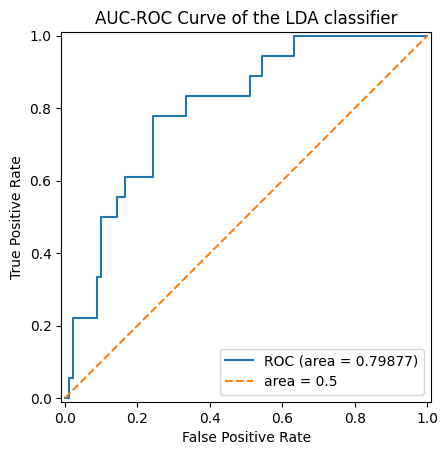

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


(1, 252)


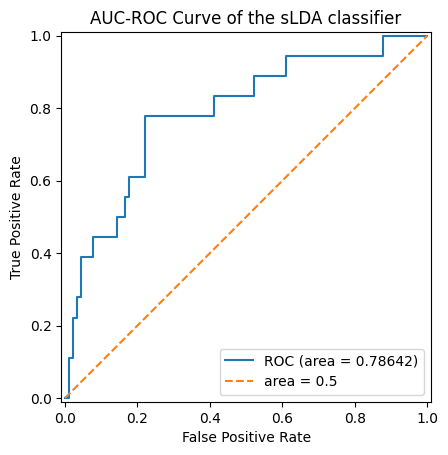

c:\Users\Soz\anaconda3\envs\thesis\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


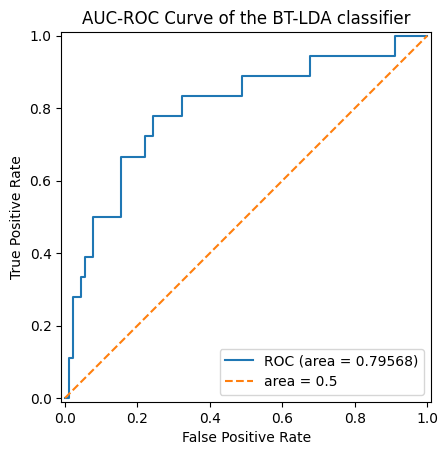

In [ ]:
# comparing LDA - BT-LDA - sLDA
# 19/04/2025_Exp_3b

# make sure data is in channel prime order by running the code block above
# evaulation method from assignment 7, ex. 3 (calibration)
# exact same auc scores as in Jan's evaluation method above

# Evaluation of ex. 3 

### LDA

lda = LDA()
ldaclf = lda.fit(X_train, y_train)
fpr, tpr, thresholds = metrics.roc_curve(y_test,ldaclf.decision_function(X_test)) # Compute signed distance of stimulus to decision boundary

auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
auc_fig.plot()
plt.plot([0, 1],[0,1], '--') 
plt.legend(['ROC (area = %0.5f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
plt.title("AUC-ROC Curve of the LDA classifier")
plt.show()

### Shrinkage LDA

slda = LDA(solver='lsqr',shrinkage = 'auto')
slda.fit(X_train, y_train)
print(slda.coef_.shape)

fpr, tpr, thresholds = metrics.roc_curve(y_test,slda.decision_function(X_test)) # Compute signed distance of stimulus to decision boundary
auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
auc_fig.plot()
plt.plot([0, 1],[0,1], '--')
plt.legend(['ROC (area = %0.5f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
plt.title("AUC-ROC Curve of the sLDA classifier")
plt.show()

### BT-LDA

# TO DO: try to set channel prime to False to let the class fix it vs manually fixing it (as done in assignment 6). See if it gives the same results 
btlda = ToeplitzLDA(n_channels= 63) 
btlda.fit(X_train, y_train) 

fpr, tpr, thresholds = metrics.roc_curve(y_test,btlda.decision_function(X_test)) # Compute signed distance of stimulus to decision boundary
auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
auc_fig.plot()
plt.plot([0, 1],[0,1], '--')
plt.legend(['ROC (area = %0.5f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
plt.title("AUC-ROC Curve of the BT-LDA classifier")
plt.show()



### 25/04/2025 Exp 6: Compare AUC of LDA vs sLDA vs BTLDA using different test_size values

In [ ]:
# 25/04/2025 Exp_6
# Update: use test_size = 0.2 and test_size = 0.3
# Note that the preprocessing here is not the same as in the real notebook/experiments! Only the code is what matters here.

def compare_auc_single_trial_interval(start, stop, test_size=0.2, only_auc = True, ival_bounds = np.array([0.1, 0.2, 0.3, 0.4, 0.5])):
    """
    compares LDA vs sLDA vs BT-LDA on calibration data
    calibration data is determined by selection trials [start - stop], e.g. [0-12]
    note that this is not robust! the interval matters
    """

    raw_calibration_trials = trials[start:stop] # change start & stop trial
    # online_trials = trials[12:] 
    clf_ival_boundaries = ival_bounds
    calibration_trials = np.array([[get_jumping_means(iteration, clf_ival_boundaries) for iteration in trial] for trial in raw_calibration_trials])
    calibration_trials_reshaped = np.array([
        [epochs.transpose(0, 2, 1) for epochs in trial] # make channel prime
        for trial in calibration_trials
    ])

    # calibration_trials has shape (12, 15, 6, 63, 4) --> calibration_trials_reshaped has shape (12, 15, 6, 4, 63)

    # finish X and y to feed into classifier
    calibration_stimuli = np.reshape(calibration_trials_reshaped, (np.prod(calibration_trials_reshaped.shape[0:3]),-1)) # new shape: (1080, 252)
    calibration_labels = np.array([[[[1 if event > 107 else 0] for event in iteration.events[:,2]] for iteration in trial] for trial in raw_calibration_trials]).flatten() # shape (1080,), contains only 0's and 1's
    #X_train, X_test, y_train, y_test = train_test_split(calibration_stimuli, calibration_labels, test_size=0.1, shuffle=False)
    # Exp 6
    X_train, X_test, y_train, y_test = train_test_split(calibration_stimuli, calibration_labels, test_size=test_size, shuffle=False)



    # Evaluation of Jan's simple toeplitz example script
    # 25/04/2025 Exp 6 update: different values for test_size
    # 19/04/2025_Exp_3a 

    print("AUC scores computed using a single train_test_split with test_size = {}".format(test_size))

    ### LDA
    clf_lda = make_pipeline(LDA(),)
    clf_lda.fit(X_train,y_train)

    y_df = clf_lda.decision_function(X_test)
    roc_auc_lda = roc_auc_score(y_test, y_df)
    y_pred = clf_lda.predict(X_test)
    bal_acc_auc_lda = balanced_accuracy_score(y_test, y_pred)

    if only_auc:
        print("AUC LDA: ", roc_auc_lda)
    else:
        print("LDA scores with channel prime data")
        print("roc_auc: ",roc_auc_lda)
        print("bal_acc_auc: ",bal_acc_auc_lda)

    ### sLDA
    clf_slda = make_pipeline(LDA(solver='lsqr', shrinkage='auto'),)
    clf_slda.fit(X_train,y_train)

    y_df = clf_slda.decision_function(X_test)
    roc_auc_slda = roc_auc_score(y_test, y_df)
    y_pred = clf_slda.predict(X_test)
    bal_acc_auc_slda = balanced_accuracy_score(y_test, y_pred)

    if only_auc:
        print("AUC SLDA: ", roc_auc_slda)
    else:     
        print("\nsLDA scores with channel prime data")
        print("roc_auc: ",roc_auc_slda)
        print("bal_acc_auc: ",bal_acc_auc_slda)

    ### BT-LDA
    # 19/04/2025: added from Jan's example_toeplitz_lda_simple.py:
    from toeplitzlda.classification import (
        EpochsVectorizer,
        ShrinkageLinearDiscriminantAnalysis,
        ToeplitzLDA,
    )

    nch = 63
    # Straightforward use toeplitz lda
    clf_btlda = make_pipeline(
        # EpochsVectorizer(
        #     select_ival=feature_ival,
        # ),
        ToeplitzLDA(n_channels=nch),
    )
    clf_btlda.fit(X_train,y_train)

    y_df = clf_btlda.decision_function(X_test)
    roc_auc_btlda = roc_auc_score(y_test, y_df)
    y_pred = clf_btlda.predict(X_test)
    bal_acc_auc_btlda = balanced_accuracy_score(y_test, y_pred)

    if only_auc:
        print("AUC BT-LDA: ", roc_auc_btlda)
    else:    
        print("\nBT-LDA scores with channel prime data")
        print("roc_auc: ",roc_auc_btlda)
        print("bal_acc_auc: ",bal_acc_auc_btlda)


    # ------------------------------------------------------------------------------------------------------------
    #
    # comparing LDA - BT-LDA - sLDA using other evaluation method
    # 25/04/2025 Exp 6 update: using different values for test_size
    # 19/04/2025_Exp_3b

    # make sure data is in channel prime order by running the code block above
    # evaulation method from assignment 7, ex. 3 (calibration)
    # exact same auc scores as in Jan's evaluation method above

    # Evaluation of ex. 3

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 1 row, 3 columns

    ### LDA

    lda = LDA()
    ldaclf = lda.fit(X_train, y_train)
    fpr_lda, tpr_lda, thresholds_lda = metrics.roc_curve(y_test,ldaclf.decision_function(X_test)) # Compute signed distance of stimulus to decision boundary

    metrics.RocCurveDisplay(fpr=fpr_lda, tpr=tpr_lda).plot(ax=axes[0])
    axes[0].plot([0, 1],[0,1], '--') 
    axes[0].legend(['ROC (area = %0.5f)' % metrics.auc(fpr_lda, tpr_lda), 'area = 0.5'], loc="lower right")
    axes[0].set_title("AUC-ROC of LDA - test_size = {}".format(test_size))

    ### Shrinkage LDA

    slda = LDA(solver='lsqr',shrinkage = 'auto')
    slda.fit(X_train, y_train)
    print(slda.coef_.shape)

    fpr_slda, tpr_slda, thresholds_slda = metrics.roc_curve(y_test,slda.decision_function(X_test)) # Compute signed distance of stimulus to decision boundary
    metrics.RocCurveDisplay(fpr=fpr_slda, tpr=tpr_slda).plot(ax=axes[1])
    axes[1].plot([0, 1],[0,1], '--')
    axes[1].legend(['ROC (area = %0.5f)' % metrics.auc(fpr_slda, tpr_slda), 'area = 0.5'], loc="lower right")
    axes[1].set_title("AUC-ROC of sLDA - test_size = {}".format(test_size))

    ### BT-LDA

    # TO DO: try to set channel prime to False to let the class fix it vs manually fixing it (as done in assignment 6). See if it gives the same results 
    btlda = ToeplitzLDA(n_channels= 63) 
    btlda.fit(X_train, y_train) 

    fpr_btlda, tpr_btlda, thresholds_btlda = metrics.roc_curve(y_test,btlda.decision_function(X_test)) # Compute signed distance of stimulus to decision boundary
    metrics.RocCurveDisplay(fpr=fpr_btlda, tpr=tpr_btlda).plot(ax=axes[2])
    axes[2].plot([0, 1],[0,1], '--')
    axes[2].legend(['ROC (area = %0.5f)' % metrics.auc(fpr_btlda, tpr_btlda), 'area = 0.5'], loc="lower right")
    axes[2].set_title("AUC-ROC of BT-LDA - test_size = {}".format(test_size))
    
    
    #plt.tight_layout()  # adjust layout nicely
    plt.show()

#### Function call

In [ ]:
# 25/04/2025 Exp 6: use different test_size values (0.2 and 0.3)
#
# 19/04/2025_Exp_3 trials [0-12] were used
# note that this evaluation is not robust, as the trial interval matters!

# train_test_split using test_size = 0.2 and test_size = 0.3
# using the time intervals [0.1, 0.2, 0.3, 0.4, 0.5]
compare_auc_single_trial_interval(0,12,0.1)
compare_auc_single_trial_interval(0,12,0.2)
compare_auc_single_trial_interval(0,12,0.3)

### Exp_? (To do if interesting): Average AUC on calibration using multiple trial samples

In [ ]:
# Note: train test split with test_size = 0.2 is used here
def compute_average_auc_calibration(classifier, trials, nch=63, tracker = False, 
                                    ival_bounds = np.array([0.1, 0.2, 0.3, 0.4, 0.5]), size = 12):
    # Check if the classifier argument is valid
    if not isinstance(classifier, str):
        raise TypeError("The classifier is not of a valid type. It should be a string")
    elif not classifier in {"lda", "slda", "btlda"}:
        raise ValueError("The provided classifier is not recognized. Only the following are supported: {lda, slda, btlda")
    
    # Initialize classifier
    if classifier == "lda":
        lda = LDA(solver='lsqr')
    elif classifier == "slda":
        lda = LDA(solver='lsqr', shrinkage='auto')    
    elif classifier == "btlda":
        lda = make_pipeline(
        ToeplitzLDA(n_channels=nch),
        )    
    else:
        raise ValueError("Unrecognized classifier") 

    end = len(trials)-1 # 35
    scores = np.zeros(end-size)
    tracker = tracker

    for i in range(end-size):
        raw_calibration_trials = trials[i:i+size]
        clf_ival_boundaries = ival_bounds
        calibration_trials = np.array([[get_jumping_means(iteration, clf_ival_boundaries) for iteration in trial] for trial in raw_calibration_trials])
        calibration_trials_reshaped = np.array([
            [epochs.transpose(0, 2, 1) for epochs in trial] # make channel prime
            for trial in calibration_trials
        ])

        # calibration_trials has shape (12, 15, 6, 63, 4) --> calibration_trials_reshaped has shape (12, 15, 6, 4, 63)

        # finish X and y to feed into classifier
        calibration_stimuli = np.reshape(calibration_trials_reshaped, (np.prod(calibration_trials_reshaped.shape[0:3]),-1)) # new shape: (1080, 252)
        calibration_labels = np.array([[[[1 if event > 107 else 0] for event in iteration.events[:,2]] for iteration in trial] for trial in raw_calibration_trials]).flatten() # shape (1080,), contains only 0's and 1's
        X_train, X_test, y_train, y_test = train_test_split(calibration_stimuli, calibration_labels, test_size=0.2, shuffle=False)


        # Fit classifier
        ldaclf = lda.fit(X_train, y_train)
        #fpr, tpr, thresholds = metrics.roc_curve(y_test,ldaclf.decision_function(X_test)) # Compute signed distance of stimulus to decision boundary

        y_df = ldaclf.decision_function(X_test)
        roc_auc_lda = roc_auc_score(y_test, y_df)
        y_pred = ldaclf.predict(X_test)
        bal_acc_auc_lda = balanced_accuracy_score(y_test, y_pred)

        if tracker:
            print ("Computing AUC for trials: {}-{} -> roc_auc = {}".format(i,i+size,roc_auc_lda))
            # print("bal_acc_auc: ",bal_acc_auc_lda)

        scores[i] = roc_auc_lda

    if tracker:
        print(scores)

    if tracker:
        print("Mean AUC of {}: {}".format(classifier,np.mean(scores)))

    return np.mean(scores)    

avg_auc_lda = compute_average_auc_calibration("lda",trials)
avg_auc_slda = compute_average_auc_calibration("slda",trials)
avg_auc_btlda = compute_average_auc_calibration("btlda",trials)

# train test split with test size = 0.2
print("avg auc lda: ",avg_auc_lda)
print("avg auc slda: ",avg_auc_slda)
print("avg auc btlda: ",avg_auc_btlda)

### 25/04/2025 Exp_7: Compare LDA - SLDA - BTLDA with K-fold cv [calibration]

#### Function for cv

In [ ]:
# Cross-validation instead of train_test_split
# LDA vs SLDA vs BT-LDA on calibration data

def compute_auc_with_cv(trials=trials, ival_bounds = np.array([0.1, 0.2, 0.3, 0.4, 0.5]), cv_folds = 4, show_only_mean = True):
    """
    if show_only_mean = False, then it also prints the auc scores of all folds. Otherwise, only the mean auc score is printed
    """
    
    raw_calibration_trials = trials[0:12] # change start & stop trial
    online_trials = trials[12:] 
    clf_ival_boundaries = ival_bounds

    calibration_trials = np.array([[get_jumping_means(iteration, clf_ival_boundaries) for iteration in trial] for trial in raw_calibration_trials])
    calibration_trials_reshaped = np.array([
        [epochs.transpose(0, 2, 1) for epochs in trial] # make channel prime
        for trial in calibration_trials
    ])

    # calibration_trials has shape (12, 15, 6, 63, 4) --> calibration_trials_reshaped has shape (12, 15, 6, 4, 63)

    # finish X and y to feed into classifier
    calibration_stimuli = np.reshape(calibration_trials_reshaped, (np.prod(calibration_trials_reshaped.shape[0:3]),-1)) # new shape: (1080, 252)
    calibration_labels = np.array([[[[1 if event > 107 else 0] for event in iteration.events[:,2]] for iteration in trial] for trial in raw_calibration_trials]).flatten() # shape (1080,), contains only 0's and 1's
    X = calibration_stimuli
    y = calibration_labels

    ### LDA
    clf_lda = make_pipeline(LDA(),)
    auc_lda = cross_val_score(clf_lda, X, y, cv=cv_folds, scoring = 'roc_auc')
    if not show_only_mean:
        print("AUC score of LDA, all 4 folds: ",auc_lda)
    print("Mean AUC score of LDA: ", auc_lda.mean())

    ### SLDA
    clf_slda = make_pipeline(LDA(solver='lsqr', shrinkage='auto'),)
    auc_slda = cross_val_score(clf_slda, X, y, cv=cv_folds, scoring = 'roc_auc')
    if not show_only_mean:
        print("AUC score of sLDA, all 4 folds: ",auc_slda)
    print("Mean AUC score of sLDA: ", auc_slda.mean())

    ### BT-LDA
    nch = 63
    clf_btlda = make_pipeline(
        ToeplitzLDA(n_channels=nch),
    )
    auc_btlda = cross_val_score(clf_btlda, X, y, cv=cv_folds, scoring = 'roc_auc')
    if not show_only_mean:
        print("AUC score of BT-LDA, all 4 folds: ",auc_btlda)
    print("Mean AUC score of BT-LDA: ", auc_btlda.mean())



#### Function call

In [ ]:
# Comparing AUC scores from cross-validation vs from a single train_test_split
# LDA vs SLDA vs BT-LDA
clf_ival_boundaries = np.array([0.1, 0.2, 0.3, 0.4, 0.5])

# Using cv
print("Using 4-fold cross-validation:")
compute_auc_with_cv(trials, ival_bounds=clf_ival_boundaries, cv_folds = 4, show_only_mean=False)

# Using single train_test_split
print("\nUsing single train test split:")
compare_auc_single_trial_interval(test_size=0.2, ival_bounds = clf_ival_boundaries, plot_roc_curves=False)

### 29/04/2025 Exp 8: Compare LDA - sLDA - BTLDA using smaller time intervals [calibration]

In [ ]:
# See 25/04/2025 Exp 7 for the compute_auc_with_cv function

# LDA vs SLDA vs BT-LDA
clf_ival_boundaries = np.array([0.1, 0.2, 0.3, 0.4, 0.5])

# Using cv
print("Using 4-fold cross-validation:")
compute_auc_with_cv(trials, ival_bounds=clf_ival_boundaries, cv_folds = 4, show_only_mean=True)

# Change: 9 time intervals of 50 ms
clf_ival_boundaries = np.array([0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5])

# Using cv
print("Using 4-fold cross-validation:")
compute_auc_with_cv(trials, ival_bounds=clf_ival_boundaries, cv_folds = 4, show_only_mean=True)


### 05/05/2025 Exp 9: Compare AUC scores using different trial intervals with train_test_split [calibration]

In [ ]:
# The function below was extended for this experiment
# Added: in the score outcomes (both plots and printed scores), the trial interval is printed too
def compare_auc_single_trial_interval(start=0, stop=12, test_size=0.2, only_auc = True, ival_bounds = np.array([0.1, 0.2, 0.3, 0.4, 0.5]), plot_roc_curves = True):
    """
    compares LDA vs sLDA vs BT-LDA on calibration data
    
    calibration data is determined by a selection of trials [start - stop], e.g. [0-12]
    note that this is not robust! the interval matters. You can check this by passing different values for [start - stop]
    The full dataset here is the selected interval of calibration data. This interval will be split with sklearn's train_test_split method.

    input:
    - start: first trial to take as calibration data
    - stop: last trial to take as calibration data
    - test_size: the test part in the ratio train:test when splitting the calibration data. 
    - only_auc: if True, only the auc scores are printed for all three classifiers. If False, then the balanced auc scores are printed too.
    - ival_bounds: time interval boundaries to average the raw calibration trials over
    - plot_roc_curves: if True, also plot the ROC curves. if False, then only the AUC scores are printed. 
    """

    raw_calibration_trials = trials[start:stop] # change start & stop trial
    # online_trials = trials[12:] 
    clf_ival_boundaries = ival_bounds
    calibration_trials = np.array([[get_jumping_means(iteration, clf_ival_boundaries) for iteration in trial] for trial in raw_calibration_trials])
    calibration_trials_reshaped = np.array([
        [epochs.transpose(0, 2, 1) for epochs in trial] # make channel prime
        for trial in calibration_trials
    ])

    # calibration_trials has shape (12, 15, 6, 63, 4) --> calibration_trials_reshaped has shape (12, 15, 6, 4, 63)

    # finish X and y to feed into classifier
    calibration_stimuli = np.reshape(calibration_trials_reshaped, (np.prod(calibration_trials_reshaped.shape[0:3]),-1)) # new shape: (1080, 252)
    calibration_labels = np.array([[[[1 if event > 107 else 0] for event in iteration.events[:,2]] for iteration in trial] for trial in raw_calibration_trials]).flatten() # shape (1080,), contains only 0's and 1's
    #X_train, X_test, y_train, y_test = train_test_split(calibration_stimuli, calibration_labels, test_size=0.1, shuffle=False)
    # Exp_6
    X_train, X_test, y_train, y_test = train_test_split(calibration_stimuli, calibration_labels, test_size=test_size, shuffle=False)

    # Evaluation of Jan's simple toeplitz example script

    print("AUC scores computed using a single train_test_split using trials [{}:{}] with test_size = {}".format(start,stop,test_size))

    ### LDA
    clf_lda = make_pipeline(LDA(),)
    clf_lda.fit(X_train,y_train)

    y_df = clf_lda.decision_function(X_test)
    roc_auc_lda = roc_auc_score(y_test, y_df)
    y_pred = clf_lda.predict(X_test)
    bal_acc_auc_lda = balanced_accuracy_score(y_test, y_pred)

    if only_auc:
        print("AUC LDA: ", roc_auc_lda)
    else:
        print("LDA scores with channel prime data")
        print("roc_auc: ",roc_auc_lda)
        print("bal_acc_auc: ",bal_acc_auc_lda)

    ### sLDA
    clf_slda = make_pipeline(LDA(solver='lsqr', shrinkage='auto'),)
    clf_slda.fit(X_train,y_train)

    y_df = clf_slda.decision_function(X_test)
    roc_auc_slda = roc_auc_score(y_test, y_df)
    y_pred = clf_slda.predict(X_test)
    bal_acc_auc_slda = balanced_accuracy_score(y_test, y_pred)

    if only_auc:
        print("AUC SLDA: ", roc_auc_slda)
    else:     
        print("\nsLDA scores with channel prime data")
        print("roc_auc: ",roc_auc_slda)
        print("bal_acc_auc: ",bal_acc_auc_slda)

    ### BT-LDA
    from toeplitzlda.classification import (
        EpochsVectorizer,
        ShrinkageLinearDiscriminantAnalysis,
        ToeplitzLDA,
    )

    nch = (trials[0][0]).info["nchan"]
    clf_btlda = make_pipeline(
        ToeplitzLDA(n_channels=nch),
    )
    clf_btlda.fit(X_train,y_train)

    y_df = clf_btlda.decision_function(X_test)
    roc_auc_btlda = roc_auc_score(y_test, y_df)
    y_pred = clf_btlda.predict(X_test)
    bal_acc_auc_btlda = balanced_accuracy_score(y_test, y_pred)

    if only_auc:
        print("AUC BT-LDA: ", roc_auc_btlda)
    else:    
        print("\nBT-LDA scores with channel prime data")
        print("roc_auc: ",roc_auc_btlda)
        print("bal_acc_auc: ",bal_acc_auc_btlda)


    # ------------------------------------------------------------------------------------------------------------
    #
    # comparing LDA - BT-LDA - sLDA using other evaluation method
    # Evaluation of ex. 3
    if plot_roc_curves:
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 1 row, 3 columns

        ### LDA

        lda = LDA()
        ldaclf = lda.fit(X_train, y_train)
        fpr_lda, tpr_lda, thresholds_lda = metrics.roc_curve(y_test,ldaclf.decision_function(X_test)) # Compute signed distance of stimulus to decision boundary

        metrics.RocCurveDisplay(fpr=fpr_lda, tpr=tpr_lda).plot(ax=axes[0])
        axes[0].plot([0, 1],[0,1], '--') 
        axes[0].legend(['ROC (area = %0.5f)' % metrics.auc(fpr_lda, tpr_lda), 'area = 0.5'], loc="lower right")
        axes[0].set_title("AUC-ROC of LDA - using trials [{}:{}] - test_size = {}".format(start,stop,test_size))

        ### Shrinkage LDA

        slda = LDA(solver='lsqr',shrinkage = 'auto')
        slda.fit(X_train, y_train)

        fpr_slda, tpr_slda, thresholds_slda = metrics.roc_curve(y_test,slda.decision_function(X_test)) # Compute signed distance of stimulus to decision boundary
        metrics.RocCurveDisplay(fpr=fpr_slda, tpr=tpr_slda).plot(ax=axes[1])
        axes[1].plot([0, 1],[0,1], '--')
        axes[1].legend(['ROC (area = %0.5f)' % metrics.auc(fpr_slda, tpr_slda), 'area = 0.5'], loc="lower right")
        axes[1].set_title("AUC-ROC of sLDA - using trials [{}:{}] - test_size = {}".format(start,stop,test_size))
        ### BT-LDA

        # TO DO: try to set channel prime to False to let the class fix it vs manually fixing it (as done in assignment 6). See if it gives the same results 
        nch = (trials[0][0]).info["nchan"]
        btlda = ToeplitzLDA(n_channels= nch) 
        btlda.fit(X_train, y_train) 

        fpr_btlda, tpr_btlda, thresholds_btlda = metrics.roc_curve(y_test,btlda.decision_function(X_test)) # Compute signed distance of stimulus to decision boundary
        metrics.RocCurveDisplay(fpr=fpr_btlda, tpr=tpr_btlda).plot(ax=axes[2])
        axes[2].plot([0, 1],[0,1], '--')
        axes[2].legend(['ROC (area = %0.5f)' % metrics.auc(fpr_btlda, tpr_btlda), 'area = 0.5'], loc="lower right")
        axes[2].set_title("AUC-ROC of BT-LDA - using trials [{}:{}] - test_size = {}".format(start,stop,test_size))
        
        plt.show()


Note that the selected interval of trials matters. Selecting trials 0-12 yields different results than trials 2-14 or 4-16, even though they have the same dataset size. This variation in scores means that a single train_test_split is not a good evaluation method to measure the general performance. 

In [ ]:
# function call
compare_auc_single_trial_interval(0,12,test_size=0.2,plot_roc_curves=False) # trials [0-12]
compare_auc_single_trial_interval(2,14,test_size=0.2,plot_roc_curves=False) # trials [2-14]
compare_auc_single_trial_interval(4,16,test_size=0.2,plot_roc_curves=False) # trials [4-16]

### 05/05/2025 Exp 10: Compare AUC scores using different trial intervals with cross-validation [calibration]

In [ ]:
# The function below was extended for this experiment
# added:
# - start & stop parameter. Now you can determine which trials to use to compute auc with cv. Before, it was trials [0-12] by default.
# - show_mean & show_folds was added
# - the nr of folds was parameterized in the print statements (before, it was fixed (4) by default).

def compute_auc_with_cv(start=0, stop=12, trials=trials, ival_bounds = np.array([0.1, 0.2, 0.3, 0.4, 0.5]), cv_folds = 4, show_mean=True, show_folds=False):
    """
    Computes and prints the average AUC score of LDA, SLDA and BTLDA using cross-validation

    input:
    - trials
    - start
    - stop
    - ival_bounds
    - cv_folds
    - show_mean: If True, print the average AUC score across all folds. If False, do not print it.
    - show_folds: if True, print the AUC scores of all folds. If False, do not print the AUC score per fold
    """

    raw_calibration_trials = trials[start:stop] 
    #online_trials = trials[stop:] 
    clf_ival_boundaries = ival_bounds

    calibration_trials = np.array([[get_jumping_means(iteration, clf_ival_boundaries) for iteration in trial] for trial in raw_calibration_trials])
    calibration_trials_reshaped = np.array([
        [epochs.transpose(0, 2, 1) for epochs in trial] # make channel prime
        for trial in calibration_trials
    ])

    # calibration_trials has shape (12, 15, 6, 63, 4) --> calibration_trials_reshaped has shape (12, 15, 6, 4, 63)

    # finish X and y to feed into classifier
    calibration_stimuli = np.reshape(calibration_trials_reshaped, (np.prod(calibration_trials_reshaped.shape[0:3]),-1)) # new shape: (1080, 252)
    calibration_labels = np.array([[[[1 if event > 107 else 0] for event in iteration.events[:,2]] for iteration in trial] for trial in raw_calibration_trials]).flatten() # shape (1080,), contains only 0's and 1's
    X = calibration_stimuli
    y = calibration_labels

    ### LDA
    clf_lda = make_pipeline(LDA(),)
    auc_lda = cross_val_score(clf_lda, X, y, cv=cv_folds, scoring = 'roc_auc')
    if show_folds:
        print("AUC score of LDA, all {} folds: {}".format(cv_folds, auc_lda))
    if show_mean:    
        print("Mean AUC score of LDA: \t\t", auc_lda.mean())

    ### SLDA
    clf_slda = make_pipeline(LDA(solver='lsqr', shrinkage='auto'),)
    auc_slda = cross_val_score(clf_slda, X, y, cv=cv_folds, scoring = 'roc_auc')
    if show_folds:
        print("AUC score of sLDA, all {} folds: {}".format(cv_folds, auc_slda))
    if show_mean:     
        print("Mean AUC score of sLDA: \t", auc_slda.mean())

    ### BT-LDA
    nch = (trials[0][0]).info["nchan"]
    clf_btlda = make_pipeline(
        ToeplitzLDA(n_channels=nch),
    )
    auc_btlda = cross_val_score(clf_btlda, X, y, cv=cv_folds, scoring = 'roc_auc')
    if show_folds:
        print("AUC score of BT-LDA, all {} folds: {}".format(cv_folds, auc_btlda))
    if show_mean:    
        print("Mean AUC score of BT-LDA: \t", auc_btlda.mean())


# Function call
# Comparing AUC scores from 4-fold cv
# LDA vs SLDA vs BT-LDA
clf_ival_boundaries = np.array([0.1, 0.2, 0.3, 0.4, 0.5])

# Using cv
print("4-fold cross-validation:")

# Trial interval matters here too... look at the difference in AUC scores when selecting different samples of the data ([0-12], [2-14], ...)
print("\nUsing interval [0-12]") # This is the default
compute_auc_with_cv(start=0, stop=12, trials=trials, ival_bounds=clf_ival_boundaries, cv_folds = 4, show_folds=False)
print("\nUsing interval [2-14]")
compute_auc_with_cv(start=2, stop=14, trials=trials, ival_bounds=clf_ival_boundaries, cv_folds = 4, show_folds=False)
print("\nUsing interval [4-16]")
compute_auc_with_cv(start=4, stop=16, trials=trials, ival_bounds=clf_ival_boundaries, cv_folds = 4, show_folds=False)
print("\nUsing interval [6-18]")
compute_auc_with_cv(start=6, stop=18, trials=trials, ival_bounds=clf_ival_boundaries, cv_folds = 4, show_folds=False)

### Functions & explanation

In [ ]:
# TO DO: change name to make_channel_prime instead of make_channels_first
# Important note! does this work as expected? double check & compare

def make_channels_first(A):
    """ Changes data matrix of shape (epochs, channels, times) to shape (epochs, times, channels). 
    
    This makes it suitable for BT-LDA where we obtain a channel-wise / channels-first structure when we concatenate features through calling the method .reshape((-1, n_features)) where n_features = times * channels
    
    First check if this input actually holds!
    Input:  data matrix A                   of shape (epochs, channels, times)
    Output: transformed data matrix A_new   of shape (epochs, times, channels)
    
    """

    # # ADDED: because we cannot do .shape for an instance of EpochsArray...
    # if type(A) is mne.epochs.EpochsArray:
    #     A = A.get_data() # returns epochs as a 3D numpy.ndarray
   
    # # Initialize our desired data matrix of shape (epochs, times, channels)
    # A_new = np.zeros((A.shape[0], A.shape[2], A.shape[1])) 

    # # For every epoch ... note that each original epoch is of shape (channels, times). 
    # for e,epoch in enumerate(A): 
        
    #     # Initialize our desired epoch of shape (times, channels)
    #     channels_first_epoch = np.zeros((epoch.shape[1],epoch.shape[0])) 

    #     # for every time interval 
    #     for t in range(epoch.shape[1]): # change this into range(epoch.shape[1])?
            
    #         # keep this time interval constant, and now stack all channels for this time interval within the epoch
    #         channels_first_epoch[t] = epoch[:,t]

    #     # add the desired epoch (where the dimensions are swapped) to our desired data matrix
    #     A_new[e] = channels_first_epoch 
    # the implementation above is old. Instead, I think the following line does exactly the same
    A_new = A.transpose(0, 2, 1)
    return A_new        




### General comments

# Note: the get_jumping_means function already converts the raw_calibration_trials (type: list) into calibration_trials (type: np.ndarray)

# Originally, raw_calibration data is of type 'list' and it contains trials, 
#             each trial is of type 'list' and contains iterations,
#             each iteration is of type 'mne.epochs.EpochsArray' and contains 6 epochs, 
#                                        which can be converted into a numpy.ndarray with .getshape()

In [16]:
# To ignore (for own understanding)

# Get jumping means takes as input 'epo', which is an iteration consisting of 6 epochs. This iteration (epo) is of shape (6, 63, 121),
# meaning 6 epochs, each with 63 channels x 121 time points. We want to change our time dimension from 121 time points to a
# specified number of time intervals. E.g., instead of using all time points, we want to use the mean of the time intervals
# from 0.1-0.2, 0.2-0.3, 0.3-0.4, and 0.4-0.5. This function does that by creating an tensor X of size (6, 63, 4) and where
# the 121 time intervals are converted into the (4) means of the specified time intervals. 
# In the example: we go from iteration/epo of shape (6, 63, 121) to shape (6, 63, 4).

def get_jumping_means(epo, boundaries):
    #print("In the function get_jumping_means)")
    #print("\nepo: \n",epo) # epo is a single iteration, containing 6 epochs/words
    
    shape_orig = epo.get_data().shape # shape is (6, 63, 121)
    
    #print("\nshape_orig = epo.get_data().shape: ", shape_orig)

    # We only change the time dimension... We want to change 121 time points into 4 (time interval means)
    X = np.zeros((shape_orig[0], shape_orig[1], len(boundaries)-1)) # shape is (6, 63, 4)
    
    #print("\nX.shape: ",X.shape, " = (6, 63, 4) = 6 times a matrix of 63 x 4")

    for i in range(len(boundaries)-1):
        idx = epo.time_as_index((boundaries[i], boundaries[i+1])) # e.g. we turn times (0.1,0.2) into sample indices (30,40)
        idx_range = list(range(idx[0], idx[1])) # e.g. for idx = [30,40], idx_range = [30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
        
        #print(epo.get_data().shape) # (6, 63, 121)
        #print(epo.get_data()[:,:,idx_range].shape) # (6, 63, 10) --> we want to take the mean of these 10 samples in our ival
        
        X[:,:,i] = epo.get_data()[:,:,idx_range].mean(axis=2) #(6, 63, 1) = (6, 63)
    return X

#### Solution
1. Shapes:
    - `calibration_trials.shape` = (12, 15, 6, 63, 4), which contains: 12 trials, 15 iterations, 6 stimuli, 63 channels, 4 time interval averages
    - `calibration_stimuli.shape` = (1080, 252), which contains: N = 1080 samples (or stimulus presentations) = 12 trials * 15 iterations * 6 stimuli, and D = 252 Features = 63 channels * 4 time interval averages 
    
   We do the reshaping because:    
   1. The classifier is performing a target/non-target classification and is not concerned by which iteration or which stimuli it is, hence the first dimenstion N.
   2. The LDA classifier takes feature vectors as input and is not exploiting the spatio-temporal aspect of the data, hence the second dimension D.

2. Shuffling is generally not a good idea when you're working with time series data. Keeping the natural trials order for the training/validation split produces results closer to an online scenario than with a shuffling. 

3. Can you find certain time intervals that lead to better classification performance? 
you'd expect the interval 250-300 ms to be of high influence. This is encapsulated in the interval 200-300ms in the default case though.

## Exercise 4: Simulated online experiment and dynamic stopping
Now it's time for the simulated online experiment! 🥳 In this exercise we will implement the early stopping method that uses a statistical test (Höhne's method).

In the online setting, we want to determine the target stimulus per trial. This is typically done at the end of the trial, however, in the case of dynamic stopping this prediction is made when we have sufficient evidence for one of the classes being the target class. To properly simulate an online experiment, you would have to treat each stimulus as if it had been just recorded. Normally, this means you would have to apply all the preprocessing steps (spectral filtering, downsampling,  etc.). We already did that for you while importing the data. So, all that is left for you to do in terms of preprocessing is extracting the features by applying the time interval averaging using the `get_jumping_means()` function (as shown in the code given below). 

#### Some information about the variables:
- `online_trial_targets` contains the target word id ($[1,2, ..,6]$) per trial. These should **only** be used to quantify the performance.
- `online_labels` contains whether the presented stimulus/word is a target (1) or a non-target (0). Note that the order of stimuli differs per iteration.
- `online_words` contains the word id ($[1,2, ..,6]$) per stimulus/word presentation. 

1. Inspect the code given below. In this code the classifier predicts the signed distance to the decision boundary, given a single presented stimulus/word. You will build on top of this code, so make sure you understand the three variables listed above.

1. **Condition A: no dynamic stopping applied.** Predict (using the provided classifier `clf`) the target words per trial, using the entire trial information. In other words, keep track of the **signed distances** to the decision hyperplane per word id throughout the entire trial to make a single prediction about the target word after all 15 iterations. Report your prediction accuracy. 
**NOTE**: The order in which words are presented differs per iteration in a trial. Also note that the classifier tried to learn a decision hyperplane such that targets have a positive signed distance to the hyperplane, and non-targets have a negative signed distance to the hyperplane.

1.  **Condition B: dynamic stopping applied.** Predict (using the provided classifier `clf`) the target words per trial while using a dynamic stopping procedure (Höhne's method). Perform a [(Welch's) t-test](https://en.wikipedia.org/wiki/Welch%27s_t-test) (look for the approriate Scipy function) per iteration to see whether you can stop the trial early. Make sure to first gather at least a few iterations before you start checking whether you can stop the trial early. You can decide on the p-value and the minimum number of iterations you wish to use. 

1. Report the average accuracy and average number of iterations per trial when using the dynamic stopping procedure with this p-value. Also convert the average number of iterations per trial to the average duration of a trial in seconds (using the sampling frequency).
    
1. Visualise:
    * The trade-off between accuracy and the p-value threshold.
    * the trade-off between the average time (s) of a trial and the p-value threshold. 
    * The trade-off between accuracy and the average time (s) of a trial.

    You can visualise this by repeating 3.4 for a range of p-value threshold values. Make use of the p-value thresholds in the range of [0.001,0.5] with a sufficiently small step size to yield a somewhat smooth plot. 

    **Note:** For 3.5 you will loop over all trials in the online experiment using different values for the p_value threshold for dynamic stopping. This can take a few minutes when you have many different values for the threshold. For fun: you can have a look at using a progress bar for your loop, they are extremely easy and useful! An example is given in a code cell below.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


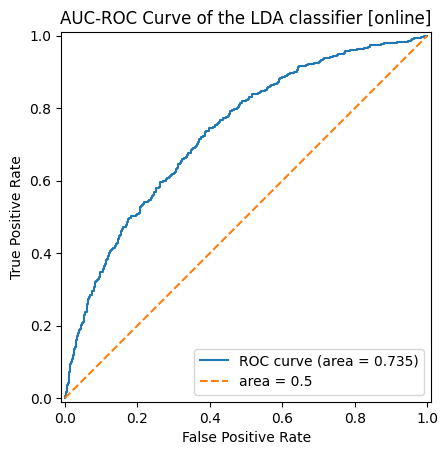

In [17]:
### This code is given and can be used in the subsequent exercises to build upon. unchanged

# Extract relevant data, labels and the played words
online_trial_targets = np.array([trial[0]["Target"].events[:,2][0] % 10 for trial in online_trials]) # The target word per trial
online_labels = np.array([[[[1 if event > 107 else 0][0] for event in iteration.events[:,2]] for iteration in trial] for trial in online_trials]) # The location of the target word in the sequence of 6 stimuli per iteration. Note that the order of stimuli differs per iteration.
online_words = np.array([[iteration.events[:,2]%10 for iteration in trial] for trial in online_trials]) # The word ID sequence that is presented per iteration. Note that the order of the presented words differs between iterations.

# 4.1: Predict target/non-target per stimulus.

signed_distances = np.zeros(online_words.shape)

for t, trial in enumerate(online_trials):
    for i, iteration in enumerate(trial):
        for s, stimulus in enumerate(iteration):
            signed_distances[t,i,s] = clf.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).flatten().reshape(1,-1))[0] # Compute signed distance of stimulus to decision boundary

fpr, tpr, thresholds = metrics.roc_curve(online_labels.flatten(),signed_distances.flatten()) 
auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
auc_fig.plot()
plt.plot([0, 1],[0,1], '--')
plt.legend(['ROC curve (area = %0.3f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
plt.title("AUC-ROC Curve of the LDA classifier [online]")
plt.show()


# TO DO: change clf to ldclf

In [18]:
# Added (to be removed)
print(online_trial_targets)
print("\nonline_labels.shape: \n",online_labels.shape)
print("\n online_labels[0]: \n",online_labels[0])
print("\n online_words.shape: \n",online_words.shape)
print("\n online_words[0]: \n",online_words[0])

[2 6 4 1 5 3 4 5 3 6 2 1 4 6 3 5 1 2 4 3 6 5 2 1]

online_labels.shape: 
 (24, 15, 6)

 online_labels[0]: 
 [[0 0 0 1 0 0]
 [0 0 0 0 0 1]
 [0 0 0 0 0 1]
 [0 0 0 0 1 0]
 [0 1 0 0 0 0]
 [0 1 0 0 0 0]
 [0 0 0 0 0 1]
 [0 0 0 0 0 1]
 [0 0 1 0 0 0]
 [0 1 0 0 0 0]
 [1 0 0 0 0 0]
 [0 0 0 0 0 1]
 [0 0 0 0 0 1]
 [0 0 1 0 0 0]
 [0 0 1 0 0 0]]

 online_words.shape: 
 (24, 15, 6)

 online_words[0]: 
 [[6 3 4 2 5 1]
 [4 6 5 3 1 2]
 [4 6 3 5 1 2]
 [4 3 5 1 2 6]
 [3 2 4 1 5 6]
 [3 2 4 6 1 5]
 [4 3 6 1 5 2]
 [1 3 5 6 4 2]
 [6 5 2 1 3 4]
 [5 2 3 1 4 6]
 [2 3 6 1 5 4]
 [3 5 6 1 4 2]
 [3 6 4 1 5 2]
 [6 5 2 3 4 1]
 [3 5 2 4 6 1]]


In [19]:
# unchanged
### [OPTIONAL]: Just for fun, you can use this function that plots the distributions of the signed distances of your candidate
###   target class vs the candidate non-target classes.
def plot_distribution_comparison(target_distances, non_target_distances): 
    signed_distances = [target_distances, non_target_distances]
    labels = ['predicted target', 'predicted non-targets']
    
    all_distances = np.concatenate((target_distances,non_target_distances),axis=None)
    x_min = np.min(all_distances)
    x_man = np.max(all_distances)
    x_axis = np.linspace(x_min, x_man)

    for i, distances in enumerate(signed_distances):
        # Fit and plot the distribution of the probabilities for the non-target words.
        mean, var  = sp.stats.distributions.norm.fit(distances)
        distri = stats.norm.pdf(x_axis,mean,np.sqrt(var))
        plt.plot(x_axis, distri, label=labels[i])

    plt.legend()
    plt.title("Distributions of the distances to the hyperplane")
    plt.xlabel("predicted distance")
    plt.ylabel("probability density function")
    plt.show()

(1, 252)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


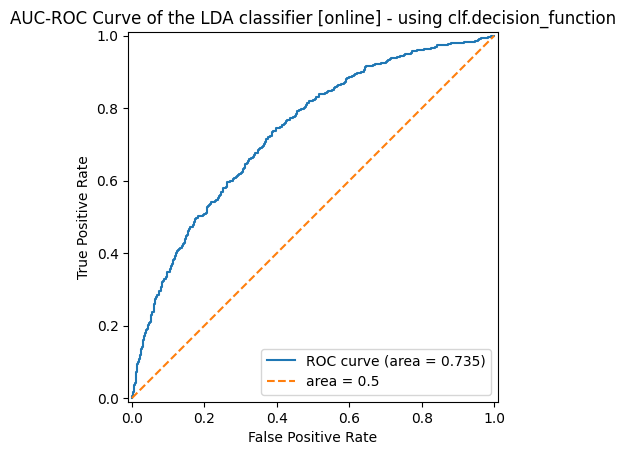

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


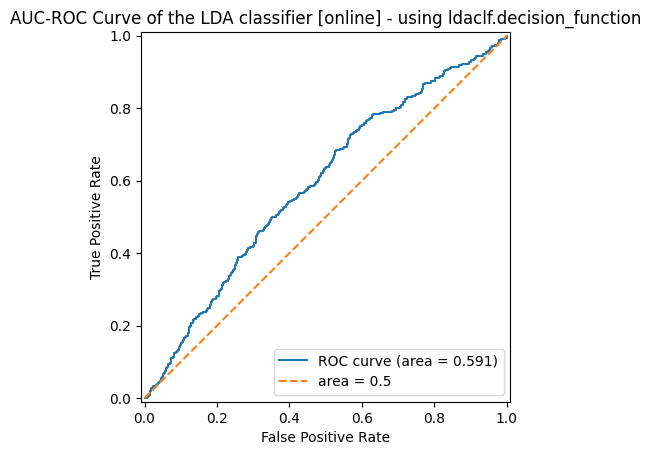

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


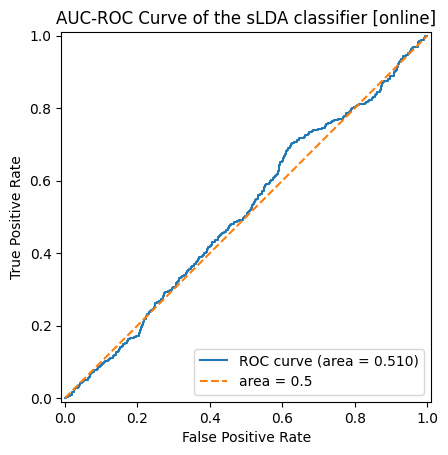

c:\Users\Soz\anaconda3\envs\thesis\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
c:\Users\Soz\anaconda3\envs\thesis\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
c:\Users\Soz\anaconda3\envs\thesis\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
c:\Users\Soz\anaconda3\envs\thesis\Lib\site-packages

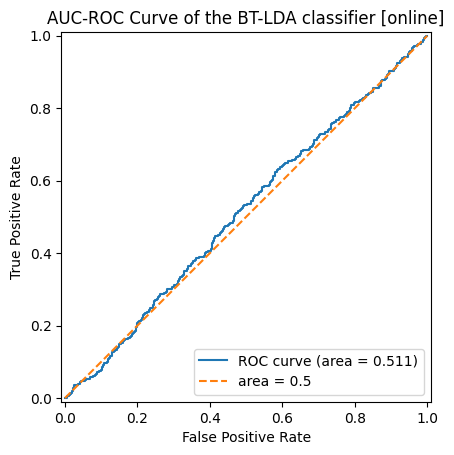

get_jumping_means(iteration[s],clf_ival_boundaries).shape: (1, 63, 4)
get_jumping_means(iteration[s],clf_ival_boundaries)flatten().shape: (252,)


c:\Users\Soz\anaconda3\envs\thesis\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


ValueError: Found array with dim 3. ToeplitzLDA expected <= 2.

In [20]:
# !!! This code was old and not working... 
# I am planning to remove this block, but I will save it temporarily in case I need anything from here later on

# Copied from above, but with modifications
# Added btlda, slda, renamed clf to lda
# Structure of X is unchanged! this has to be changed to a proper structure for BT-LDA
# TO DO: inspect structure of X and make it channel-prime


# added for debugging
lda = LDA()
ldaclf = lda.fit(X_train, y_train)
print(ldaclf.coef_.shape)

btlda = ToeplitzLDA(n_channels=63)
btlda.fit(X_train, y_train)

slda = LDA(solver='lsqr',shrinkage='auto')
slda.fit(X_train, y_train)

# from before
# X_train, X_test, y_train, y_test = train_test_split(calibration_stimuli, calibration_labels, test_size=0.1, shuffle=False)
# clf = LDA().fit(X_train, y_train)


# 4.1: Predict target/non-target per stimulus.

signed_distances = np.zeros(online_words.shape)
#lda = clf

### LDA

for t, trial in enumerate(online_trials):
    for i, iteration in enumerate(trial):
        for s, stimulus in enumerate(iteration):
            signed_distances[t,i,s] = clf.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).flatten().reshape(1,-1))[0] 
            #print(lda.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).flatten().reshape(1,-1)).shape)
            # Compute signed distance of stimulus to decision boundary

fpr, tpr, thresholds = metrics.roc_curve(online_labels.flatten(),signed_distances.flatten()) 
auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
auc_fig.plot()
plt.plot([0, 1],[0,1], '--')
plt.legend(['ROC curve (area = %0.3f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
plt.title("AUC-ROC Curve of the LDA classifier [online] - using clf.decision_function")
plt.show()

### LDA

for t, trial in enumerate(online_trials):
    for i, iteration in enumerate(trial):
        for s, stimulus in enumerate(iteration):
            signed_distances[t,i,s] = ldaclf.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).flatten().reshape(1,-1))[0] 
            #print(lda.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).flatten().reshape(1,-1)).shape)
            # Compute signed distance of stimulus to decision boundary

fpr, tpr, thresholds = metrics.roc_curve(online_labels.flatten(),signed_distances.flatten()) 
auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
auc_fig.plot()
plt.plot([0, 1],[0,1], '--')
plt.legend(['ROC curve (area = %0.3f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
plt.title("AUC-ROC Curve of the LDA classifier [online] - using ldaclf.decision_function")
plt.show()

### sLDA

signed_distances = np.zeros(online_words.shape)
slda = slda

for t, trial in enumerate(online_trials):
    for i, iteration in enumerate(trial):
        for s, stimulus in enumerate(iteration):
            signed_distances[t,i,s] = slda.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).flatten().reshape(1,-1))[0] # Compute signed distance of stimulus to decision boundary

fpr, tpr, thresholds = metrics.roc_curve(online_labels.flatten(),signed_distances.flatten()) 
auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
auc_fig.plot()
plt.plot([0, 1],[0,1], '--')
plt.legend(['ROC curve (area = %0.3f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
plt.title("AUC-ROC Curve of the sLDA classifier [online]")
plt.show()

### BT-LDA

signed_distances = np.zeros(online_words.shape)
#btlda = btlda

for t, trial in enumerate(online_trials):
    for i, iteration in enumerate(trial):
        for s, stimulus in enumerate(iteration):

            # TO DO: debugging
            #print(get_jumping_means(iteration[s],clf_ival_boundaries).flatten().reshape(-1,1).shape) # I flipped dimensions to (251, 1) instead

            # TO DO: fix output: btlda.decision_function returns something of shape ()...
            #print(type(btlda))
            #print(btlda.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).flatten().reshape(1,-1)).shape)
            
            
            signed_distances[t,i,s] = btlda.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).flatten().reshape(1,-1)) 

            #signed_distances[t,i,s] = btlda.decision_function(make_channels_first(get_jumping_means(iteration[s],clf_ival_boundaries))).flatten().reshape(1,-1)


            # Compute signed distance of stimulus to decision boundary

fpr, tpr, thresholds = metrics.roc_curve(online_labels.flatten(),signed_distances.flatten()) 
auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
auc_fig.plot()
plt.plot([0, 1],[0,1], '--')
plt.legend(['ROC curve (area = %0.3f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
plt.title("AUC-ROC Curve of the BT-LDA classifier [online]")
plt.show()

### BT-LDA

signed_distances = np.zeros(online_words.shape)
#btlda = btlda

i = 0
for t, trial in enumerate(online_trials):
    for i, iteration in enumerate(trial):
        for s, stimulus in enumerate(iteration):

            # TO DO: debugging
            #print(get_jumping_means(iteration[s],clf_ival_boundaries).flatten().reshape(-1,1).shape) # I flipped dimensions to (251, 1) instead

            # TO DO: fix output: btlda.decision_function returns something of shape ()...
            #print(type(btlda))
            #print(btlda.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).flatten().reshape(1,-1)).shape)
            
            
            #signed_distances[t,i,s] = btlda.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).flatten().reshape(1,-1)) 
            i += 1
            if i == i:
                print("get_jumping_means(iteration[s],clf_ival_boundaries).shape:", get_jumping_means(iteration[s],clf_ival_boundaries).shape)
                print("get_jumping_means(iteration[s],clf_ival_boundaries)flatten().shape:", get_jumping_means(iteration[s],clf_ival_boundaries).flatten().shape)
                o = get_jumping_means(iteration[s],clf_ival_boundaries)

            signed_distances[t,i,s] = btlda.decision_function(make_channels_first(get_jumping_means(iteration[s],clf_ival_boundaries))).reshape(1,-1)


            # Compute signed distance of stimulus to decision boundary

fpr, tpr, thresholds = metrics.roc_curve(online_labels.flatten(),signed_distances.flatten()) 
auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
auc_fig.plot()
plt.plot([0, 1],[0,1], '--')
plt.legend(['ROC curve (area = %0.3f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
plt.title("AUC-ROC Curve of the BT-LDA classifier [online] - attempt to make it channel-prime")
plt.show()

### LDA vs sLDA vs BT-LDA

In [ ]:
# added 21/04/2025: copied from above + modifications
# modifications:
# - changed clf to ldaclf which is trained on channel prime data (do not apply clf on new, channel prime data as this has not been trained on this structure. i.e., be consistent with the data structure in both fitting and testing/applying)
# - added some comments 
# - changed input to decision_function to be channel-prime through .transpose(0,2,1)
# - added slda and btlda


# added from a nr of blocks above -----------------------------------------------------
    # Run 19/04/2025_Exp_1

# Evaluation of ex. 3 

### LDA

# lda = LDA()
# ldaclf = lda.fit(X_train, y_train)
ldaclf = make_pipeline(LDA(),)
ldaclf.fit(X_train,y_train)
fpr, tpr, thresholds = metrics.roc_curve(y_test,ldaclf.decision_function(X_test)) # Compute signed distance of stimulus to decision boundary

### Shrinkage LDA

# slda = LDA(solver='lsqr',shrinkage = 'auto')
# slda.fit(X_train, y_train)
slda = make_pipeline(LDA(solver='lsqr', shrinkage='auto'),)
slda.fit(X_train,y_train)

### BT-LDA

# btlda = ToeplitzLDA(n_channels= 63) 
# btlda.fit(X_train, y_train) 

btlda = make_pipeline(
    ToeplitzLDA(n_channels=63),
)
btlda.fit(X_train,y_train)

# -------------------------------------------------------------------------------


# Extract relevant data, labels and the played words
online_trial_targets = np.array([trial[0]["Target"].events[:,2][0] % 10 for trial in online_trials]) # The target word per trial
online_labels = np.array([[[[1 if event > 107 else 0][0] for event in iteration.events[:,2]] for iteration in trial] for trial in online_trials]) # The location of the target word in the sequence of 6 stimuli per iteration. Note that the order of stimuli differs per iteration.
online_words = np.array([[iteration.events[:,2]%10 for iteration in trial] for trial in online_trials]) # The word ID sequence that is presented per iteration. Note that the order of the presented words differs between iterations.

# 4.1: Predict target/non-target per stimulus.

signed_distances_lda = np.zeros(online_words.shape) # (24, 15, 6)
signed_distances_slda = np.zeros(online_words.shape) # (24, 15, 6)
signed_distances_btlda = np.zeros(online_words.shape) # (24, 15, 6)
# online_trials has shape (24, 15, 6, 63, 121)
print(clf_ival_boundaries)

p = 0
for t, trial in enumerate(online_trials):
    for i, iteration in enumerate(trial):
        for s, stimulus in enumerate(iteration):
                        
            # changed to channel prime for bt-lda
            signed_distances_lda[t,i,s] = ldaclf.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).transpose(0,2,1).flatten().reshape(1,-1))[0] # Compute signed distance of stimulus to decision boundary
            
            signed_distances_slda[t,i,s] = slda.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).transpose(0,2,1).flatten().reshape(1,-1))[0]

            # print(get_jumping_means(iteration[s],clf_ival_boundaries).transpose(0,2,1).flatten().reshape(1,-1).shape)
            # print(slda.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).transpose(0,2,1).flatten().reshape(1,-1)).shape)
            # print(btlda.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).transpose(0,2,1).flatten().reshape(1,-1)).shape)
            # print(type(slda))
            # print(type(btlda))
            # print(btlda)
            # print(type(btlda.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).transpose(0,2,1).flatten().reshape(1,-1))))  # <class 'numpy.ndarray'>
            # print(type(btlda.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).transpose(0,2,1).flatten().reshape(1,-1)).item()))  # a float 
            # print((btlda.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).transpose(0,2,1).flatten().reshape(1,-1)).item()))

            # Important note during debugging
            # btlda.decision_function returns an nd array of shape (). To access its value, you have to call .item() additionally, instead of taking the first element via [0] (as done for lda and slda)
            signed_distances_btlda[t,i,s] = btlda.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).transpose(0,2,1).flatten().reshape(1,-1)).item()

            # ignore (for understanding)
            # if (p==1):
            #     print(get_jumping_means(iteration[s], clf_ival_boundaries).shape) # (1, 63, 4)
            #     print(get_jumping_means(iteration[s], clf_ival_boundaries).transpose(0,2,1).shape) # (1, 63, 4)
            #     a = get_jumping_means(iteration[s], clf_ival_boundaries)
            #     b =get_jumping_means(iteration[s], clf_ival_boundaries).transpose(0,2,1)
            #     print(np.allclose(a.flatten(),b.flatten()))
            #     print(get_jumping_means(iteration[s], clf_ival_boundaries).flatten().shape) # (252,)
            #     print(get_jumping_means(iteration[s], clf_ival_boundaries).flatten().reshape(1,-1).shape) # (1, 252)
            #     print(clf.decision_function(get_jumping_means(iteration[s], clf_ival_boundaries).flatten().reshape(1,-1))) # [-2.43789348] 


fpr, tpr, thresholds = metrics.roc_curve(online_labels.flatten(),signed_distances_lda.flatten()) 
auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
auc_fig.plot()
plt.plot([0, 1],[0,1], '--')
plt.legend(['ROC curve (area = %0.5f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
plt.title("AUC-ROC Curve of the LDA classifier [online]")
plt.show()


fpr, tpr, thresholds = metrics.roc_curve(online_labels.flatten(),signed_distances_slda.flatten()) 
auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
auc_fig.plot()
plt.plot([0, 1],[0,1], '--')
plt.legend(['ROC curve (area = %0.5f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
plt.title("AUC-ROC Curve of the sLDA classifier [online]")
plt.show()


fpr, tpr, thresholds = metrics.roc_curve(online_labels.flatten(),signed_distances_btlda.flatten()) 
auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
auc_fig.plot()
plt.plot([0, 1],[0,1], '--')
plt.legend(['ROC curve (area = %0.5f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
plt.title("AUC-ROC Curve of the BT-LDA classifier [online]")
plt.show()



In [ ]:
print(o.shape)
print(make_channels_first(o).shape)

(1, 63, 4)
(1, 4, 63)


In [ ]:
### Answer here for 4.2 (Condition A, no dynamic stopping applied)

In [ ]:
### Answer here for 4.3 & 4.4 (Condition B, dynamic stopping applied + reporting the average accuracy and trial duration)

In [ ]:
### Example progress bar code, super useful and easy to use!
# You might have to run this once if you don't yet have the package:
#!pip install tqdm

import time
from tqdm.notebook import tqdm

array = np.arange(1,100,1)
for i, item in enumerate(tqdm(array)):
    time.sleep(0.02)

  0%|          | 0/99 [00:00<?, ?it/s]

In [ ]:
### Answer here for 4.5 (Visualisation of the trade-offs)

Trial 0 target prediction: word 2 with p-value of 0.000175
Trial 1 target prediction: word 6 with p-value of 0.025187
Trial 2 target prediction: word 4 with p-value of 0.000184
Trial 3 target prediction: word 1 with p-value of 0.092229
Trial 4 target prediction: word 5 with p-value of 0.000241
Trial 5 target prediction: word 3 with p-value of 0.000084
Trial 6 target prediction: word 4 with p-value of 0.000829
Trial 7 target prediction: word 5 with p-value of 0.000050
Trial 8 target prediction: word 3 with p-value of 0.000812
Trial 9 target prediction: word 6 with p-value of 0.075389
Trial 10 target prediction: word 2 with p-value of 0.007437
Trial 11 target prediction: word 1 with p-value of 0.000134
Trial 12 target prediction: word 5 with p-value of 0.010921
Trial 13 target prediction: word 6 with p-value of 0.013190
Trial 14 target prediction: word 3 with p-value of 0.001186
Trial 15 target prediction: word 5 with p-value of 0.267428
Trial 16 target prediction: word 1 with p-value of

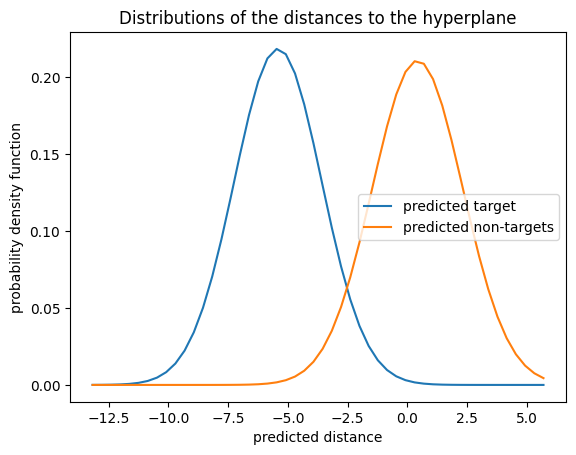

Accuracy: 0.88


In [ ]:
# Solution 4.2
trial_predictions = np.zeros(online_trial_targets.shape)
for t, trial in enumerate(online_trials):
    stim_distances = np.zeros(online_labels.shape[1:3])
    for i, iteration in enumerate(trial):
        for s, stimulus in enumerate(iteration):
            played_word = online_words[t,i,s] - 1 # to convert to indices
            stim_distances[i,played_word] = clf.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).flatten().reshape(1,-1))[0] # Compute signed distance of stimulus to decision boundary
            
    means = np.mean(stim_distances, axis=0) # get the mean distance for each word
    best_guess = np.argmax(means)
    best_distances = stim_distances[:, best_guess].flatten()
    not_best_distances = stim_distances[:,np.arange(stim_distances.shape[1])!=best_guess].flatten()
    t_score, p = stats.ttest_ind(best_distances, not_best_distances, equal_var = False)
    trial_predictions[t] = best_guess + 1
    print("Trial %d target prediction: word %d with p-value of %0.6f" % (t, best_guess+1, p))    

plot_distribution_comparison(not_best_distances, best_distances)
print("Accuracy: %0.2f" % np.mean(trial_predictions == online_trial_targets))

In [ ]:
# Solution 4.3 & 4.4

trial_predictions = np.zeros(online_trial_targets.shape)
trial_times = np.zeros(online_trial_targets.shape)

p_threshold = 0.1

for t, trial in enumerate(online_trials):
    stim_distances = np.zeros(online_labels.shape[1:3])
    for i, iteration in enumerate(trial):
        for s, stimulus in enumerate(iteration):
            played_word = online_words[t,i,s] - 1 # to convert to indices
            stim_distances[i,played_word] = clf.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).flatten().reshape(1,-1))[0] # Compute signed distance of stimulus to decision boundary
        if (i>5): # after 5/15 iteration
            means = np.mean(stim_distances, axis=0) # get the mean distance for each word
            best_guess = np.argmax(means)
            best_dist = stim_distances[:, best_guess].flatten()
            not_best_dist = stim_distances[:,np.arange(stim_distances.shape[1])!=best_guess].flatten()
            t_score, p_val = stats.ttest_ind(best_dist, not_best_dist, equal_var = False) # equal_var = False gives us welch's t-test
            
            # Dynamic stopping
            if p_val<p_threshold or i==len(trial)-1:
                trial_times[t] = i
                trial_predictions[t] = best_guess + 1
                print("Trial %d was predicted with class %d after %d iterations with p-value of %0.6f" % (t, best_guess+1, i, p)) 
                break


_,_,n_stimuli,_, n_samples = np.array(online_trials).shape

# convert to seconds
print("Each iteration takes: %0.2f seconds to complete" % (n_stimuli*n_samples/epochs.info["sfreq"]))
trial_time_seconds = trial_times*(n_stimuli*n_samples/epochs.info["sfreq"]) 

print("The experiment took %0.2f seconds to complete" % np.sum(trial_time_seconds))
print("Each trial taking %0.2f seconds on average" % np.mean(trial_time_seconds))
print("The experiment achieved %0.2f %% accuracy" % (np.mean(trial_predictions == online_trial_targets)*100))


Trial 0 was predicted with class 2 after 6 iterations with p-value of 0.000020
Trial 1 was predicted with class 6 after 8 iterations with p-value of 0.000020
Trial 2 was predicted with class 4 after 6 iterations with p-value of 0.000020
Trial 3 was predicted with class 1 after 13 iterations with p-value of 0.000020
Trial 4 was predicted with class 5 after 6 iterations with p-value of 0.000020
Trial 5 was predicted with class 3 after 6 iterations with p-value of 0.000020
Trial 6 was predicted with class 4 after 6 iterations with p-value of 0.000020
Trial 7 was predicted with class 5 after 6 iterations with p-value of 0.000020
Trial 8 was predicted with class 3 after 6 iterations with p-value of 0.000020
Trial 9 was predicted with class 6 after 6 iterations with p-value of 0.000020
Trial 10 was predicted with class 1 after 6 iterations with p-value of 0.000020
Trial 11 was predicted with class 1 after 6 iterations with p-value of 0.000020
Trial 12 was predicted with class 1 after 6 itera

In [ ]:
print(best_dist)
print(not_best_dist)

[-0.0614656  -2.58344812  0.10335954 -3.52346143  2.91485361 -9.03651175
  1.47490863  0.          0.          0.          0.          0.
  0.          0.          0.        ]
[ -3.74200694  -4.15245081  -4.71362542  -5.10232963  -2.57360692
  -8.83247766  -3.18231051  -9.63821338  -5.81336401   4.97147001
  -4.40846216  -5.21778471  -6.26923514  -5.89335557  -7.12675296
  -4.18804977  -5.17905841  -7.00607164  -7.84797104  -4.46278271
  -7.41385914  -3.16105154  -4.47897914  -9.63030666  -9.77689614
  -2.49623678 -11.91201474  -7.43603397  -3.61510024  -3.37624585
  -2.67936687 -11.92912714  -4.83109723  -0.53223581  -5.10945776
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.         

In [ ]:
# Solution 4.5

from tqdm.notebook import tqdm

n_trials,n_iterations,n_stimuli,_, n_samples = np.array(online_trials).shape
p_thresholds = np.arange(start=0.01,stop=0.5,step=0.01)
n_p_thresholds = p_thresholds.shape[0]

p_accuracy = np.zeros((n_p_thresholds))
p_trial_times = np.zeros((n_p_thresholds, n_trials))

for p, p_threshold in enumerate(p_thresholds):
    trial_predictions = np.zeros(n_trials)
    for t, trial in enumerate(online_trials):
        stim_distances = np.zeros(online_labels.shape[1:3])
        for i, iteration in enumerate(trial):
            for s, stimulus in enumerate(iteration):
                played_word = online_words[t,i,s] - 1 # to convert to indices
                stim_distances[i,played_word] = clf.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).flatten().reshape(1,-1))[0] # Compute signed distance of stimulus to decision boundary
            if (i>4):
                means = np.mean(stim_distances, axis=0) # get the mean distance for each word
                best_guess = np.argmax(means)
                best_dist = stim_distances[:, best_guess].flatten()
                not_best_dist = stim_distances[:,np.arange(stim_distances.shape[1])!=best_guess].flatten()
                t_score, p_val = stats.ttest_ind(best_dist, not_best_dist, equal_var = False)
                # Dynamic stopping
                if p_val<p_threshold or i==len(trial)-1:
                    p_trial_times[p][t] = i
                    trial_predictions[t] = best_guess + 1
                    break
    p_accuracy[p] = np.mean(trial_predictions == online_trial_targets)*100


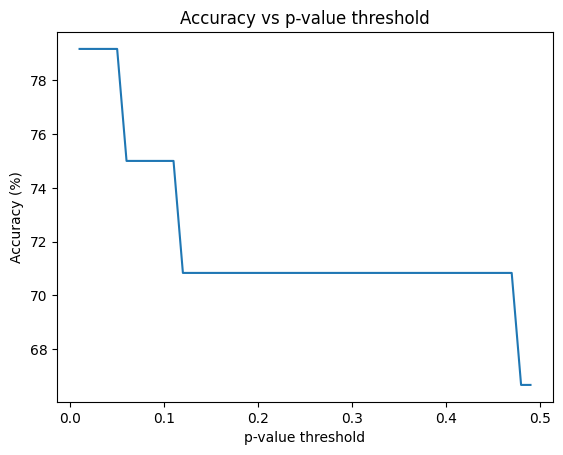

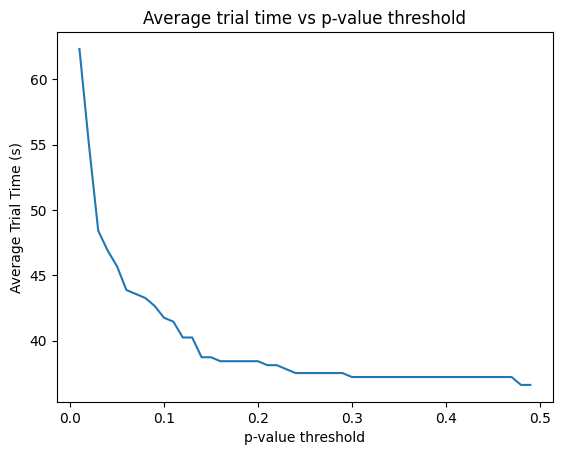

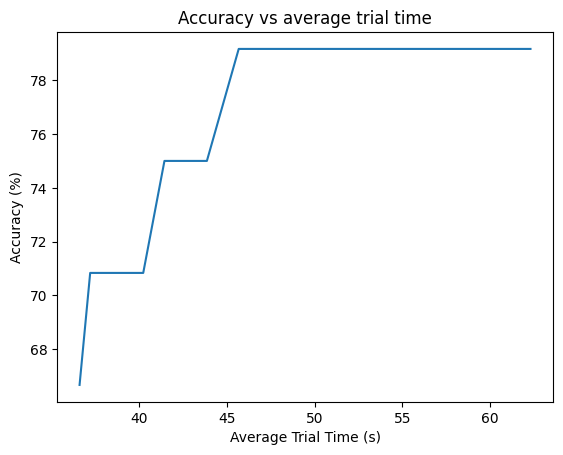

In [ ]:
# 4.5 continued
# convert trial times from iterations to seconds
trial_time_seconds = p_trial_times*(n_stimuli*n_samples/epochs.info["sfreq"]) 

plt.plot(p_thresholds, p_accuracy)
plt.title("Accuracy vs p-value threshold")
plt.xlabel('p-value threshold')
plt.ylabel('Accuracy (%)')
plt.show()

plt.plot(p_thresholds, np.mean(trial_time_seconds,axis=1))
plt.title("Average trial time vs p-value threshold")
plt.ylabel('Average Trial Time (s)')
plt.xlabel('p-value threshold')
plt.show()

plt.plot(np.mean(trial_time_seconds, axis = 1), p_accuracy)
plt.title("Accuracy vs average trial time")
plt.xlabel('Average Trial Time (s)')
plt.ylabel('Accuracy (%)')
plt.show()


# Ethics


## Exercise 5: discussion about an ethics topic
In this exercise we want you to get creative.
As mentioned in the lecture, certain aspects of BCI can have ethical concerns. A few examples of such aspects are:

    - Mind reading;
    - User identification;
    - Media expectation management;
    - Shared control (responsibility);
    - BCI illiteracy/defiency.
This is by no means an exhaustive list.

1. Dive into the ethics of an aspect of BCI you're interested in and introduce your peers (group) to your chosen topic and its ethics by creating and posting *one* of the following on the discussion board:
    * An informational video 
    * A short report/summary document
    * A video/written summary of a discussion that you had amongst your teammates
    * Any other medium you want to use! 🥳

## Exercise 0: Who did what?
Please provide a short description on who contributed what to your submission.

> Answer here